# Import

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import shutil
import glob
import random
import json
from pathlib import Path
from google.colab import drive

import os
import sys
import warnings
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings("ignore")

In [ ]:
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import tensorflow as tf
tf_version = tuple(int(x) for x in tf.__version__.split(".")[:2])

if tf_version >= (2, 16):
    try:
        import tf_keras as keras
        from tf_keras import layers, models, callbacks, regularizers
        print("[INFO] Menggunakan tf_keras (TF >= 2.16)")
    except ImportError:
        os.system("pip install tf-keras -q")
        import tf_keras as keras
        from tf_keras import layers, models, callbacks, regularizers
else:
    keras = tf.keras
    from tensorflow.keras import layers, models, callbacks, regularizers
    print("[INFO] Menggunakan tf.keras (TF < 2.16)")

# Mixed Precision
if tf.config.list_physical_devices('GPU'):
    keras.mixed_precision.set_global_policy('mixed_float16')
    print("[INFO] Mixed precision aktif (float16)")
else:
    print("[INFO] GPU tidak tersedia, pakai float32 default")

print(f"[OK] TensorFlow versi : {tf.__version__}")
print(f"[OK] Keras versi      : {keras.__version__}")
print(f"[OK] GPU tersedia     : {len(tf.config.list_physical_devices('GPU')) > 0}")

[INFO] Menggunakan tf_keras (TF >= 2.16)
[INFO] Mixed precision aktif (float16)
[OK] TensorFlow versi : 2.20.0
[OK] Keras versi      : 2.20.0
[OK] GPU tersedia     : True


# Akuisisi Data

In [ ]:
drive.mount('/content/drive')
PROJECT_ROOT = '/content/drive/Shareddrives/Projek PCD'
DATASET_PATH = os.path.join(PROJECT_ROOT, 'MMU-Iris-Database')
OUTPUT_PATH  = os.path.join(PROJECT_ROOT, 'output')

PREPROC_PATH = os.path.join(OUTPUT_PATH, 'preprocessed')
SEG_PATH = os.path.join(OUTPUT_PATH, 'segmented')
NORM_PATH = os.path.join(OUTPUT_PATH, 'normalized')
MODEL_PATH = os.path.join(OUTPUT_PATH, 'models')
AUG_PATH = os.path.join(OUTPUT_PATH, 'augmented')
PREPROC_VIS_PATH = os.path.join(PREPROC_PATH, 'visualizations')
SEG_VIS_PATH = os.path.join(SEG_PATH, 'visualizations')
DETECTION_JSON_PATH = os.path.join(SEG_PATH, 'detection_results.json')

for folder in [PREPROC_PATH, SEG_PATH, NORM_PATH, MODEL_PATH, AUG_PATH,
               PREPROC_VIS_PATH, SEG_VIS_PATH]:
    os.makedirs(folder, exist_ok=True)

random.seed(42)
np.random.seed(42)
print(f"Output akan disimpan di: {OUTPUT_PATH}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Output akan disimpan di: /content/drive/Shareddrives/Projek PCD/output


In [ ]:
def explore_dataset(dataset_path):
    dataset_info = {}
    total_images = 0

    for person_id in sorted(os.listdir(dataset_path)):
        person_folder = os.path.join(dataset_path, person_id)
        if not os.path.isdir(person_folder):
            continue

        left_images  = []
        right_images = []

        left_folder = os.path.join(person_folder, 'left')
        if os.path.exists(left_folder):
            for ext in ['*.bmp', '*.BMP', '*.jpg', '*.JPG', '*.png', '*.PNG']:
                left_images += glob.glob(os.path.join(left_folder, ext))
            left_images = sorted(left_images)

        right_folder = os.path.join(person_folder, 'right')
        if os.path.exists(right_folder):
            for ext in ['*.bmp', '*.BMP', '*.jpg', '*.JPG', '*.png', '*.PNG']:
                right_images += glob.glob(os.path.join(right_folder, ext))
            right_images = sorted(right_images)

        if left_images or right_images:
            dataset_info[person_id] = {'left': left_images, 'right': right_images}
            total_images += len(left_images) + len(right_images)

    return dataset_info, total_images

dataset_info, total_images = explore_dataset(DATASET_PATH)

print("=" * 40)
print("HASIL EKSPLORASI DATASET MMU IRIS")
print("=" * 40)
print(f"Jumlah individu   : {len(dataset_info)}")
print(f"Total gambar      : {total_images}")
print()

print("Sampel 5 individu pertama:")
for i, (pid, data) in enumerate(list(dataset_info.items())[:5]):
    print(f"  Individu {pid:>3}: {len(data['left'])} mata kiri, {len(data['right'])} mata kanan")

HASIL EKSPLORASI DATASET MMU IRIS
Jumlah individu   : 45
Total gambar      : 450

Sampel 5 individu pertama:
  Individu   1: 5 mata kiri, 5 mata kanan
  Individu  10: 5 mata kiri, 5 mata kanan
  Individu  11: 5 mata kiri, 5 mata kanan
  Individu  12: 5 mata kiri, 5 mata kanan
  Individu  13: 5 mata kiri, 5 mata kanan


# Load All Data

In [ ]:
def load_all_dataset_paths(dataset_path):
    all_data = []
    total_images = 0

    print("Memuat path seluruh dataset...")
    for person_id in sorted(os.listdir(dataset_path)):
        person_dir = os.path.join(dataset_path, person_id)
        if not os.path.isdir(person_dir):
            continue

        for side in ['left', 'right']:
            side_dir = os.path.join(person_dir, side)
            if os.path.isdir(side_dir):
                for img_name in os.listdir(side_dir):
                    if img_name.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
                        img_path = os.path.join(side_dir, img_name)
                        all_data.append({
                            'person_id': person_id,
                            'side': side,
                            'path': img_path
                        })
                        total_images += 1

    print(f"Berhasil memuat {total_images} gambar dari dataset.")
    return all_data, total_images

all_image_data, total_images = load_all_dataset_paths(DATASET_PATH)
print(f"Total data yang akan diproses: {total_images} gambar")

Memuat path seluruh dataset...
Berhasil memuat 450 gambar dari dataset.
Total data yang akan diproses: 450 gambar


# Pra-Pemrosesan

In [ ]:
def remove_specular_reflection(gray_img, bright_thresh=240, dilate_iter=3):
    _, mask = cv2.threshold(gray_img, bright_thresh, 255, cv2.THRESH_BINARY)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mask_dilated = cv2.dilate(mask, kernel, iterations=dilate_iter)
    result = cv2.inpaint(gray_img, mask_dilated, inpaintRadius=3, flags=cv2.INPAINT_TELEA)
    return result, mask_dilated

def apply_clahe(gray_img, clip_limit=2.0, tile_size=(8, 8)):
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_size)
    result = clahe.apply(gray_img)
    return result

def preprocess_image(img_path, bright_thresh=240, clip_limit=2.0):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Gagal membaca: {img_path}")
    img_no_spec, spec_mask = remove_specular_reflection(img, bright_thresh)
    img_clahe = apply_clahe(img_no_spec, clip_limit)
    return img, img_no_spec, spec_mask, img_clahe

print("Fungsi pra-pemrosesan siap!")

Fungsi pra-pemrosesan siap!


In [ ]:
print("Memulai Pra-Pemrosesan")
preproc_success_count = 0
preproc_failure_count = 0

preproc_results = []

for idx, data_entry in enumerate(all_image_data):
    print(f"Pra-Proses [{idx+1}/{total_images}]: {data_entry['path']}", end='\r')

    try:
        img_orig, img_no_spec, spec_mask, img_clahe = preprocess_image(data_entry['path'])

        person_id = data_entry['person_id']
        side = data_entry['side']
        preproc_subdir = os.path.join(PREPROC_PATH, person_id, side)
        os.makedirs(preproc_subdir, exist_ok=True)

        base_filename = os.path.splitext(os.path.basename(data_entry['path']))[0]
        preproc_output_path = os.path.join(preproc_subdir, f"{base_filename}_clahe.jpg")
        cv2.imwrite(preproc_output_path, img_clahe)

        preproc_results.append({
            'person_id': person_id,
            'side': side,
            'src_path': data_entry['path'],
            'preproc_path': preproc_output_path
        })

        preproc_success_count += 1

    except Exception as e:
        print(f"\n Error pra-pemrosesan {data_entry['path']}: {e}")
        preproc_failure_count += 1

print(f"\nPra-pemrosesan Selesai!")
print(f"  Berhasil: {preproc_success_count}")
print(f"  Gagal: {preproc_failure_count}")

Memulai Pra-Pemrosesan

Pra-pemrosesan Selesai!
  Berhasil: 450
  Gagal: 0


# Deteksi Batas Iris

In [ ]:
def detect_pupil_via_threshold(gray_img):
    h, w = gray_img.shape
    min_dim = min(h, w)
    blurred = cv2.GaussianBlur(gray_img, (7, 7), 1.5)
    _, binary = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=2)
    binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel, iterations=2)
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    min_area = np.pi * (min_dim * 0.05) ** 2
    max_area = np.pi * (min_dim * 0.22) ** 2
    pupil_candidates = []
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < min_area or area > max_area:
            continue
        perimeter = cv2.arcLength(cnt, True)
        if perimeter == 0:
            continue
        circularity = 4 * np.pi * area / (perimeter ** 2)
        if circularity > 0.55:
            pupil_candidates.append((circularity, cnt))
    if not pupil_candidates:
        return None
    pupil_candidates.sort(key=lambda x: x[0], reverse=True)
    best_cnt = pupil_candidates[0][1]
    (cx, cy), radius = cv2.minEnclosingCircle(best_cnt)
    return (int(cx), int(cy), int(radius))

def detect_iris_relative_to_pupil(gray_img, pupil):
    h, w = gray_img.shape
    min_dim = min(h, w)
    px, py, pr = pupil
    blurred = cv2.GaussianBlur(gray_img, (11, 11), 2)
    r_min = max(int(pr * 1.8), int(min_dim * 0.18))
    r_max = min(int(pr * 5.0), int(min_dim * 0.55))
    iris_circles = cv2.HoughCircles(blurred, cv2.HOUGH_GRADIENT, dp=1.0, minDist=int(min_dim * 0.15),
                                    param1=60, param2=25, minRadius=r_min, maxRadius=r_max)
    if iris_circles is None:
        return None
    iris_circles = np.round(iris_circles[0, :]).astype(int)
    max_center_dist = min_dim * 0.15
    best_iris = None
    best_score = -1
    for (cx, cy, r) in iris_circles:
        dist = np.sqrt((cx - px)**2 + (cy - py)**2)
        if dist > max_center_dist:
            continue
        ratio = r / pr
        if not (2.0 <= ratio <= 5.0):
            continue
        if r <= pr:
            continue
        score = -dist
        if score > best_score:
            best_score = score
            best_iris = (cx, cy, r)
    return best_iris

def detect_iris_boundaries(gray_img):
    h, w = gray_img.shape
    min_dim = min(h, w)
    pupil = detect_pupil_via_threshold(gray_img)
    if pupil is None:
        blurred = cv2.GaussianBlur(gray_img, (9, 9), 2)
        pc = cv2.HoughCircles(blurred, cv2.HOUGH_GRADIENT, dp=1.2, minDist=50, param1=50, param2=25,
                              minRadius=int(min_dim*0.04), maxRadius=int(min_dim*0.20))
        if pc is not None:
            pc = np.round(pc[0]).astype(int)
            darkest, pupil = 999, None
            for (cx, cy, r) in pc:
                mask = np.zeros_like(gray_img)
                cv2.circle(mask, (cx, cy), r, 255, -1)
                mv = cv2.mean(gray_img, mask=mask)[0]
                if mv < darkest:
                    darkest, pupil = mv, (cx, cy, r)
    if pupil is None:
        pupil = (w//2, h//2, int(min_dim * 0.10))
        print(f" Pupil fallback digunakan")
    iris = detect_iris_relative_to_pupil(gray_img, pupil)
    if iris is None:
        iris = (pupil[0], pupil[1], int(pupil[2] * 3.0))
        print(f" Iris fallback digunakan")
    return pupil, iris

def segment_iris(gray_img, pupil, iris_b):
    """Create annular mask and segment iris region"""
    h, w = gray_img.shape
    mask = np.zeros((h, w), dtype=np.uint8)

    # Create annular mask (between pupil and iris boundaries)
    cv2.circle(mask, (pupil[0], pupil[1]), iris_b[2], 255, -1)
    cv2.circle(mask, (pupil[0], pupil[1]), pupil[2], 0, -1)

    # Morphological operations to smooth mask
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=2)

    # Apply mask to original image
    segmented = cv2.bitwise_and(gray_img, gray_img, mask=mask)

    return mask, segmented

print("Fungsi deteksi siap!")

Fungsi deteksi siap!


# Segmentasi Iris

In [ ]:
def segment_all_images(preproc_results, output_seg_path):
    seg_results = []
    count_success  = 0
    count_fallback = 0
    count_error    = 0

    for idx, item in enumerate(preproc_results):
        person_id = item['person_id']
        side      = item['side']
        img_path  = item['preproc_path']

        try:
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                print(f"  Tidak bisa baca: {img_path}")
                count_error += 1
                continue

            # Detect boundaries
            pupil, iris_b = detect_iris_boundaries(img)

            # Fallback jika gagal
            is_fallback = False
            if pupil is None or iris_b is None:
                h, w        = img.shape
                cx, cy      = w // 2, h // 2
                r_iris_fb   = int(min(h, w) * 0.40)
                r_pupil_fb  = int(r_iris_fb * 0.35)
                pupil       = (cx, cy, r_pupil_fb)
                iris_b      = (cx, cy, r_iris_fb)
                is_fallback = True
                count_fallback += 1

            mask, segmented = segment_iris(img, pupil, iris_b)

            # Save
            out_dir  = os.path.join(output_seg_path, person_id, side)
            os.makedirs(out_dir, exist_ok=True)
            fname    = os.path.basename(img_path)
            out_path = os.path.join(out_dir, fname)
            cv2.imwrite(out_path, segmented)

            seg_results.append({
                'person_id'   : person_id,
                'side'        : side,
                'src_path'    : item['src_path'],
                'preproc_path': img_path,
                'seg_path'    : out_path,
                'pupil'       : pupil,
                'iris'        : iris_b,
                'is_fallback' : is_fallback
            })
            count_success += 1
            if count_success % 50 == 0:
                print(f"  Segmentasi: {count_success} gambar berhasil...")

        except Exception as e:
            print(f"  Error pada {img_path}: {e}")
            count_error += 1

    print(f"\nBerhasil  : {count_success} gambar")
    print(f"  Fallback  : {count_fallback} gambar (pakai center-crop estimate)")
    print(f"  Error     : {count_error} gambar")

    return seg_results

print("Menjalankan segmentasi untuk semua gambar...")
seg_results = segment_all_images(preproc_results, SEG_PATH)
print(f"\nSegmentasi selesai! Total berhasil: {len(seg_results)} gambar.")
print(f"Tersimpan di: {SEG_PATH}")

Menjalankan segmentasi untuk semua gambar...
 Iris fallback digunakan
 Iris fallback digunakan
 Iris fallback digunakan
 Iris fallback digunakan
 Iris fallback digunakan
 Iris fallback digunakan
 Iris fallback digunakan
 Iris fallback digunakan
 Iris fallback digunakan
 Iris fallback digunakan
 Iris fallback digunakan
 Iris fallback digunakan
 Iris fallback digunakan
 Iris fallback digunakan
 Iris fallback digunakan
 Iris fallback digunakan
 Iris fallback digunakan
 Iris fallback digunakan
 Iris fallback digunakan
 Iris fallback digunakan
 Iris fallback digunakan
 Iris fallback digunakan
 Iris fallback digunakan
 Iris fallback digunakan
 Iris fallback digunakan
 Iris fallback digunakan
 Iris fallback digunakan
 Iris fallback digunakan
 Iris fallback digunakan
 Iris fallback digunakan
 Iris fallback digunakan
 Iris fallback digunakan
 Iris fallback digunakan
 Iris fallback digunakan
 Iris fallback digunakan
 Iris fallback digunakan
 Iris fallback digunakan
 Iris fallback digunakan
 Iris

# Normalisasi

> Daugman Rubber Sheet

In [ ]:
def daugman_rubber_sheet_fast(img, pupil, iris, radial_resolution=64, angular_resolution=512):
    h, w = img.shape
    px, py, r_pupil = pupil
    ix, iy, r_iris = iris

    # Center point
    cx = (px + ix) // 2
    cy = (py + iy) // 2

    # Create output image
    polar_img = np.zeros((radial_resolution, angular_resolution), dtype=np.uint8)

    # Pre-calculate angles
    angles = np.linspace(0, 2 * np.pi, angular_resolution, endpoint=False)
    cos_theta = np.cos(angles)
    sin_theta = np.sin(angles)

    # Iterate over radius (normalized)
    for r_idx in range(radial_resolution):
        r_ratio = r_idx / radial_resolution

        # Calculate interpolation coordinates
        x_pupil = cx + (px - cx) * (1 - r_ratio) + (ix - cx) * r_ratio
        y_pupil = cy + (py - cy) * (1 - r_ratio) + (iy - cy) * r_ratio
        r_curr = int(r_pupil * (1 - r_ratio) + r_iris * r_ratio)

        # Sample points along the circle
        x_circ = (x_pupil + r_curr * cos_theta).astype(int)
        y_circ = (y_pupil + r_curr * sin_theta).astype(int)

        # Bound check
        valid = (x_circ >= 0) & (x_circ < w) & (y_circ >= 0) & (y_circ < h)
        valid_indices = np.where(valid)[0]

        if len(valid_indices) > 0:
            polar_img[r_idx, valid_indices] = img[y_circ[valid_indices], x_circ[valid_indices]]

    return polar_img

In [ ]:
def normalize_all_images(seg_results, output_norm_path,
                          radial_res=64, angular_res=512, target_size=(96, 96)):
    norm_results = []
    count        = 0
    count_error  = 0

    for idx, item in enumerate(seg_results):
        try:
            img = cv2.imread(item['seg_path'], cv2.IMREAD_GRAYSCALE)
            if img is None:
                count_error += 1
                continue

            # Rubber Sheet
            normalized_polar = daugman_rubber_sheet_fast(
                img,
                item['pupil'],
                item['iris'],
                radial_resolution=radial_res,
                angular_resolution=angular_res
            )

            # Resize
            normalized_resized = cv2.resize(
                normalized_polar, target_size,
                interpolation=cv2.INTER_LINEAR
            )

            # Convert to RGB (3 channel)
            normalized_rgb = cv2.cvtColor(normalized_resized, cv2.COLOR_GRAY2RGB)

            # Save
            out_dir = os.path.join(output_norm_path, item['person_id'], item['side'])
            os.makedirs(out_dir, exist_ok=True)

            base_fname = os.path.splitext(os.path.basename(item['seg_path']))[0]
            out_path = os.path.join(out_dir, f"{base_fname}_norm.jpg")

            cv2.imwrite(out_path, normalized_rgb)

            norm_results.append({
                'person_id' : item['person_id'],
                'side'      : item['side'],
                'src_path'  : item.get('src_path', item['seg_path']),
                'norm_path' : out_path,
                'label'     : item['person_id']
            })

            count += 1
            if count % 50 == 0:
                print(f"  Normalisasi: {count} gambar...")

        except Exception as e:
            print(f"  Error pada {item.get('seg_path', 'Unknown')}: {e}")
            count_error += 1

    print(f"\nBerhasil : {count} gambar ({target_size[0]}x{target_size[1]} RGB tersimpan)")
    print(f"Error    : {count_error} gambar")
    return norm_results

# Run normalization
print("\nMenjalankan normalisasi untuk semua gambar...")
norm_results = normalize_all_images(
    seg_results,
    NORM_PATH,
    radial_res=64,
    angular_res=512,
    target_size=(96, 96)
)

print(f"\nNormalisasi selesai! Total: {len(norm_results)} gambar.")
print(f"Tersimpan di: {NORM_PATH}")


Menjalankan normalisasi untuk semua gambar...
  Normalisasi: 50 gambar...
  Normalisasi: 100 gambar...
  Normalisasi: 150 gambar...
  Normalisasi: 200 gambar...
  Normalisasi: 250 gambar...
  Normalisasi: 300 gambar...
  Normalisasi: 350 gambar...
  Normalisasi: 400 gambar...
  Normalisasi: 450 gambar...

Berhasil : 450 gambar (96x96 RGB tersimpan)
Error    : 0 gambar

Normalisasi selesai! Total: 450 gambar.
Tersimpan di: /content/drive/Shareddrives/Projek PCD/output/normalized


# Split Data

In [ ]:
import os

def load_norm_results_from_disk(norm_path):
    """
    Rekonstruksi norm_results dari folder hasil normalisasi yang sudah tersimpan.
    Struktur folder yang dibaca: norm_path/person_id/side/filename

    Return: norm_results — list of dicts, identik dengan output normalize_all_images()
    """
    norm_results  = []
    ekstensi_valid = ('.png', '.jpg', '.jpeg', '.bmp')

    if not os.path.exists(norm_path):
        raise FileNotFoundError(f"Folder normalisasi tidak ditemukan: {norm_path}")

    for person_id in sorted(os.listdir(norm_path)):
        person_dir = os.path.join(norm_path, person_id)
        if not os.path.isdir(person_dir):
            continue

        for side in ['left', 'right']:
            side_dir = os.path.join(person_dir, side)
            if not os.path.isdir(side_dir):
                continue

            for fname in sorted(os.listdir(side_dir)):
                if not fname.lower().endswith(ekstensi_valid):
                    continue

                norm_path_file = os.path.join(side_dir, fname)
                norm_results.append({
                    'person_id' : person_id,
                    'side'      : side,
                    'norm_path' : norm_path_file,
                    'label'     : person_id   # label = person_id untuk LabelEncoder
                })

    return norm_results


# Cek isi folder normalisasi
TOTAL_EXPECTED = 450

if os.path.exists(NORM_PATH) and len(os.listdir(NORM_PATH)) > 0:
    print("Folder normalisasi ditemukan. Membaca langsung dari disk...")
    norm_results = load_norm_results_from_disk(NORM_PATH)

    # Validasi jumlah gambar
    print(f"Total gambar dimuat     : {len(norm_results)}")
    print(f"Total gambar diharapkan : {TOTAL_EXPECTED}")

    if len(norm_results) == TOTAL_EXPECTED:
        print("Validasi OK: semua 450 gambar berhasil dimuat.")
    else:
        print(f"Peringatan: selisih {abs(len(norm_results) - TOTAL_EXPECTED)} gambar.")
        print("Cek folder normalisasi atau jalankan ulang normalize_all_images().")

    # Validasi distribusi per individu
    from collections import Counter
    dist = Counter(item['person_id'] for item in norm_results)
    n_persons     = len(dist)
    count_values  = list(dist.values())
    print(f"\nJumlah individu         : {n_persons}")
    print(f"Gambar per individu     : min={min(count_values)}, max={max(count_values)}")

    if n_persons == 45 and all(v == 10 for v in count_values):
        print("Distribusi aman! 45 individu × 10 gambar.")
    else:
        print("Peringatan: distribusi tidak merata, cek hasil normalisasi.")

else:
    print("Folder normalisasi belum ada atau kosong.")
    print("Jalankan cell normalisasi terlebih dahulu.")
    norm_results = []

# Tampilkan sampel untuk verifikasi
if norm_results:
    print(f"\nSampel norm_results[0] : {norm_results[0]}")
    print(f"Sampel norm_results[-1]: {norm_results[-1]}")

Folder normalisasi ditemukan. Membaca langsung dari disk...
Total gambar dimuat     : 450
Total gambar diharapkan : 450
Validasi OK: semua 450 gambar berhasil dimuat.

Jumlah individu         : 45
Gambar per individu     : min=10, max=10
Distribusi aman! 45 individu × 10 gambar.

Sampel norm_results[0] : {'person_id': '1', 'side': 'left', 'norm_path': '/content/drive/Shareddrives/Projek PCD/output/normalized/1/left/aeval1_clahe_norm.jpg', 'label': '1'}
Sampel norm_results[-1]: {'person_id': '9', 'side': 'right', 'norm_path': '/content/drive/Shareddrives/Projek PCD/output/normalized/9/right/fatmar5_clahe_norm.jpg', 'label': '9'}


In [ ]:
print("Split Data")

# Semua 45 individu tetap ada di kedua split
labels_for_split = [item['person_id'] for item in norm_results]

train_norm_results, test_norm_results = train_test_split(
    norm_results,
    test_size=0.2,
    random_state=42,
    stratify=labels_for_split
)

# Verifikasi: kedua split harus punya 45 individu
n_train_persons = len(set(i['person_id'] for i in train_norm_results))
n_test_persons  = len(set(i['person_id'] for i in test_norm_results))

print(f"Data Train : {len(train_norm_results)} gambar | {n_train_persons} individu")
print(f"Data Test  : {len(test_norm_results)} gambar  | {n_test_persons} individu")
assert n_train_persons == 45, "Ada individu yang tidak masuk training!"
assert n_test_persons  == 45, "Ada individu yang tidak masuk test!"
print("Aman!, semua 45 individu terwakili di kedua split")

Split Data
Data Train : 360 gambar | 45 individu
Data Test  : 90 gambar  | 45 individu
Aman!, semua 45 individu terwakili di kedua split


# Augmentasi Data

In [ ]:
def augment_horizontal_shift(img, shift_range=0.1):
    h, w = img.shape[:2]
    max_shift = int(w * shift_range)
    shift_px = random.randint(-max_shift, max_shift)
    shifted = np.roll(img, shift_px, axis=1)
    return shifted, shift_px

def augment_brightness(img, factor_range=(0.7, 1.3)):
    factor = random.uniform(factor_range[0], factor_range[1])
    brightened = np.clip(img.astype(np.float32) * factor, 0, 255).astype(np.uint8)
    return brightened, factor

def augment_train_images_flat(train_norm_results, output_aug_path, n_augment_per_image=2):
    aug_results = []
    count_orig = 0
    count_aug = 0

    print("Memulai augmentasi data training...")
    for idx, item in enumerate(train_norm_results):
        print(f"Augmentasi [{idx+1}/{len(train_norm_results)}]: {item['person_id']}", end='\r')

        try:
            img_bgr = cv2.imread(item['norm_path'])
            img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

            out_dir = os.path.join(output_aug_path, item['person_id'], item['side'])
            os.makedirs(out_dir, exist_ok=True)

            fname = os.path.splitext(os.path.basename(item['norm_path']))[0]

            # Save ORIGINAL
            orig_path = os.path.join(out_dir, f"{fname}_orig.jpg")
            cv2.imwrite(orig_path, cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR))

            aug_results.append({
                'person_id': item['person_id'],
                'side': item['side'],
                'label': item['label'],
                'img_path': orig_path,
                'is_augmented': False
            })
            count_orig += 1

            # Horizontal Shift augmentation
            for aug_i in range(n_augment_per_image):
                aug_img, _ = augment_horizontal_shift(img_rgb, shift_range=0.12)
                aug_path = os.path.join(out_dir, f"{fname}_hshift{aug_i}.jpg")
                cv2.imwrite(aug_path, cv2.cvtColor(aug_img, cv2.COLOR_RGB2BGR))

                aug_results.append({
                    'person_id': item['person_id'],
                    'side': item['side'],
                    'label': item['label'],
                    'img_path': aug_path,
                    'is_augmented': True,
                    'aug_type': 'hshift'
                })
                count_aug += 1

            # Brightness augmentation
            for aug_i in range(n_augment_per_image):
                aug_img, _ = augment_brightness(img_rgb, factor_range=(0.7, 1.3))
                aug_path = os.path.join(out_dir, f"{fname}_bright{aug_i}.jpg")
                cv2.imwrite(aug_path, cv2.cvtColor(aug_img, cv2.COLOR_RGB2BGR))

                aug_results.append({
                    'person_id': item['person_id'],
                    'side': item['side'],
                    'label': item['label'],
                    'img_path': aug_path,
                    'is_augmented': True,
                    'aug_type': 'brightness'
                })
                count_aug += 1

        except Exception as e:
            print(f"\n  Error augmentasi pada {item['norm_path']}: {e}")

    print(f"\nAugmentasi Selesai!")
    print(f"  Gambar training asli    : {count_orig}")
    print(f"  Gambar hasil augmentasi : {count_aug}")
    print(f"  Total data training     : {count_orig + count_aug} gambar")

    return aug_results, count_orig, count_aug

# Run augmentation
print("\nMenjalankan pipeline augmentasi...")
aug_train_results, n_orig, n_aug = augment_train_images_flat(
    train_norm_results,
    AUG_PATH,
    n_augment_per_image=2
)
print("=" * 40)
print(f"\nHASIL AUGMENTASI")
print("=" * 40)
print(f"Gambar training asli    : {n_orig}")
print(f"Gambar hasil augmentasi : {n_aug}")
print(f"Total data training     : {n_orig + n_aug} gambar")
if n_orig > 0:
    print(f"Peningkatan data        : {(n_orig + n_aug)/n_orig:.1f}x lebih banyak")
print(f"   Tersimpan di: {AUG_PATH}")


Menjalankan pipeline augmentasi...
Memulai augmentasi data training...

Augmentasi Selesai!
  Gambar training asli    : 360
  Gambar hasil augmentasi : 1440
  Total data training     : 1800 gambar

HASIL AUGMENTASI
Gambar training asli    : 360
Gambar hasil augmentasi : 1440
Total data training     : 1800 gambar
Peningkatan data        : 5.0x lebih banyak
   Tersimpan di: /content/drive/Shareddrives/Projek PCD/output/augmented


# MobileNetV2

## Encode Labels

In [ ]:
import numpy as np
import pandas as pd
import joblib
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from sklearn.model_selection import StratifiedKFold

# Label encoder
le = LabelEncoder()
all_labels = [item['label'] for item in aug_train_results]
encoded_labels = le.fit_transform(all_labels)

semua_label = (
    [item['label'] for item in aug_train_results] +
    [item['label'] for item in test_norm_results]
)
le.fit(semua_label)

print(f"Jumlah kelas diketahui LabelEncoder: {len(le.classes_)}")
print(f"Contoh kelas: {le.classes_[:5]}")  # Verifikasi semua 45 ada

# Encode training
encoded_train_labels = le.transform([item['label'] for item in aug_train_results])
for i, item in enumerate(aug_train_results):
    item['encoded_label'] = encoded_train_labels[i]

# Encode test — sekarang tidak akan error lagi
encoded_test_labels = le.transform([item['label'] for item in test_norm_results])
for i, item in enumerate(test_norm_results):
    item['encoded_label'] = encoded_test_labels[i]

# Simpan encoder
encoder_path = os.path.join(MODEL_PATH, 'label_encoder.pkl')
joblib.dump(le, encoder_path)
print(f"Label encoder disimpan di: {encoder_path}")

Jumlah kelas diketahui LabelEncoder: 45
Contoh kelas: ['1' '10' '11' '12' '13']
Label encoder disimpan di: /content/drive/Shareddrives/Projek PCD/output/models/label_encoder.pkl


## Data Generator

In [ ]:
def build_data_generator(data_list, batch_size=32, shuffle=True, augment=False):
    def generator():
        for item in data_list:
            img_path = item['img_path'] if 'img_path' in item else item['norm_path']
            img = cv2.imread(img_path)
            if img is None:
                print(f"Warning: Could not read image {img_path}")
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (96, 96))
            img = preprocess_input(img.astype(np.float32))

            yield img, item['encoded_label']

    ds = tf.data.Dataset.from_generator(
        generator,
        output_signature=(
            tf.TensorSpec(shape=(96, 96, 3), dtype=tf.float32),
            tf.TensorSpec(shape=(), dtype=tf.int32)
        )
    )

    if shuffle:
        ds = ds.shuffle(buffer_size=1000)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

## Membangun Model

In [ ]:
def build_model(num_classes, dropout_rate=0.2, l2_reg=1e-4):
    base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(96, 96, 3))

    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(dropout_rate)(x)
    predictions = layers.Dense(num_classes, activation='softmax',
                                kernel_regularizer=regularizers.l2(l2_reg))(x)

    model = models.Model(inputs=base_model.input, outputs=predictions)
    return model, base_model

# Plot history per fold, fase 1 dan fase 2 terpisah
EPOCH_FASE1 = 50

def plot_training_history_split(history_gabung, fold_ke, save_dir, epoch_fase1=None):
    if epoch_fase1 is None:
        epoch_fase1 = history_gabung.get('epoch_fase1', EPOCH_FASE1)

    total_epoch = len(history_gabung['accuracy'])
    epoch_fase2 = total_epoch - epoch_fase1

    # Split manual berdasarkan jumlah epoch fase 1
    history_p1 = {
        'accuracy':     history_gabung['accuracy'][:epoch_fase1],
        'val_accuracy': history_gabung['val_accuracy'][:epoch_fase1],
        'loss':         history_gabung['loss'][:epoch_fase1],
        'val_loss':     history_gabung['val_loss'][:epoch_fase1],
    }
    history_p2 = {
        'accuracy':     history_gabung['accuracy'][epoch_fase1:],
        'val_accuracy': history_gabung['val_accuracy'][epoch_fase1:],
        'loss':         history_gabung['loss'][epoch_fase1:],
        'val_loss':     history_gabung['val_loss'][epoch_fase1:],
    }

    print(f"\nFold {fold_ke} — Total epoch: {total_epoch} "
          f"(Fase 1: {epoch_fase1}, Fase 2: {epoch_fase2})")

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle(f'Training History — Fold {fold_ke}', fontsize=14, fontweight='bold')

    # Fase 1: Accuracy
    axes[0, 0].plot(history_p1['accuracy'],     label='Training', color='steelblue')
    axes[0, 0].plot(history_p1['val_accuracy'], label='Validasi', color='orange')
    axes[0, 0].set_title('Fase 1 — Accuracy (Backbone Beku)')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Accuracy')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # Fase 1: Loss
    axes[1, 0].plot(history_p1['loss'],     label='Training', color='steelblue')
    axes[1, 0].plot(history_p1['val_loss'], label='Validasi', color='orange')
    axes[1, 0].set_title('Fase 1 — Loss (Backbone Beku)')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Loss')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # Fase 2: Accuracy
    axes[0, 1].plot(history_p2['accuracy'],     label='Training', color='steelblue')
    axes[0, 1].plot(history_p2['val_accuracy'], label='Validasi', color='orange')
    axes[0, 1].set_title('Fase 2 — Accuracy (Fine-Tuning)')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # Fase 2: Loss
    axes[1, 1].plot(history_p2['loss'],     label='Training', color='steelblue')
    axes[1, 1].plot(history_p2['val_loss'], label='Validasi', color='orange')
    axes[1, 1].set_title('Fase 2 — Loss (Fine-Tuning)')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Loss')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()

    # Simpan tanpa menimpa file yang sudah ada
    save_path = os.path.join(save_dir, f'history_fold_{fold_ke}.png')
    if not os.path.exists(save_path):
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Grafik disimpan: {save_path}")
    else:
        print(f"File sudah ada, tidak ditimpa: {save_path}")

    plt.show()

# lama
def evaluate_overfitting(histories):
    print("\nEvaluasi Overfitting")

    val_accs = [max(hist['val_accuracy']) for hist in histories]
    train_accs = [max(hist['accuracy']) for hist in histories]
    val_losses = [min(hist['val_loss']) for hist in histories]
    train_losses = [min(hist['loss']) for hist in histories]

    mean_val_acc = np.mean(val_accs)
    std_val_acc = np.std(val_accs)
    mean_train_acc = np.mean(train_accs)
    mean_val_loss = np.mean(val_losses)
    mean_train_loss = np.mean(train_losses)

    gap_acc_mean = mean_train_acc - mean_val_acc
    gap_loss_mean = mean_train_loss - mean_val_loss

    print(f"Rata-rata Akurasi Val: {mean_val_acc:.4f} (+/- {std_val_acc * 2:.4f})")
    print(f"Rata-rata Akurasi Train: {mean_train_acc:.4f}")
    print(f"Rata-rata Loss Val: {mean_val_loss:.4f}")
    print(f"Rata-rata Loss Train: {mean_train_loss:.4f}")
    print(f"Gap Akurasi (Train - Val): {gap_acc_mean:.4f}")
    print(f"Gap Loss (Train - Val): {gap_loss_mean:.4f}")
    print(f"Std Akurasi Val (variance): {std_val_acc:.4f}")

    if gap_acc_mean > 0.05:
        print("Potensi overfitting terdeteksi (gap akurasi besar).")
    elif std_val_acc > 0.02:
        print("Variansi akurasi antar fold tinggi, mungkin overfitting atau data tidak stabil.")
    else:
        print("Model tampak stabil, gap akurasi/loss rendah.")

## Two Phase Training

In [ ]:
def run_two_phase_training(train_gen, val_gen, num_classes, fold_num):
    model, base_model = build_model(num_classes, dropout_rate=0.2, l2_reg=1e-4)

    # Phase 1: Feature Extraction
    print(f"\nFold {fold_num} - Fase 1: Feature Extraction")
    base_model.trainable = False

    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    checkpoint_p1 = ModelCheckpoint(
        filepath=os.path.join(MODEL_PATH, f'model_fold_{fold_num}_phase1_best.h5'),
        monitor='val_loss',
        save_best_only=True,
        save_weights_only=True,
        verbose=1
    )
    es_callback_p1 = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    callbacks_p1 = [checkpoint_p1, es_callback_p1]

    history_p1 = model.fit(
        train_gen,
        epochs=50,
        validation_data=val_gen,
        callbacks=callbacks_p1,
        verbose=1
    )

    # TAMBAH satu key untuk mencatat epoch aktual fase 1
    actual_epoch_fase1 = len(history_p1.history['loss'])

    combined_history = {
        'loss': history_p1.history['loss'] + history_p2.history['loss'],
        'accuracy': history_p1.history['accuracy'] + history_p2.history['accuracy'],
        'val_loss': history_p1.history['val_loss'] + history_p2.history['val_loss'],
        'val_accuracy': history_p1.history['val_accuracy'] + history_p2.history['val_accuracy'],
        'epoch_fase1': actual_epoch_fase1,
    }

    # Phase 2: Fine-Tuning
    print(f"\nFold {fold_num} - Fase 2: Fine-Tuning")
    base_model.trainable = True

    fine_tune_at = len(base_model.layers) - 30
    for layer in base_model.layers[:fine_tune_at]:
        layer.trainable = False

    model.compile(
        optimizer=Adam(learning_rate=1e-5),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    checkpoint_final = ModelCheckpoint(
        filepath=os.path.join(MODEL_PATH, f'model_fold_{fold_num}_best.h5'),
        monitor='val_loss',
        save_best_only=True,
        save_weights_only=True,
        verbose=1
    )
    es_callback_p2 = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    callbacks_p2 = [checkpoint_final, es_callback_p2]

    history_p2 = model.fit(
        train_gen,
        epochs=50,
        validation_data=val_gen,
        callbacks=callbacks_p2,
        verbose=1
    )

    combined_history = {
        'loss': history_p1.history['loss'] + history_p2.history['loss'],
        'accuracy': history_p1.history['accuracy'] + history_p2.history['accuracy'],
        'val_loss': history_p1.history['val_loss'] + history_p2.history['val_loss'],
        'val_accuracy': history_p1.history['val_accuracy'] + history_p2.history['val_accuracy'],
    }

    history_path = os.path.join(MODEL_PATH, f'history_fold_{fold_num}.pkl')
    joblib.dump(combined_history, history_path)
    print(f"History Fold {fold_num} disimpan di: {history_path}")

    plot_title = f'Training History - Fold {fold_num}'
    plot_path = os.path.join(MODEL_PATH, f'train_val_plot_fold_{fold_num}.png')
    plot_training_history_split(combined_history, fold_ke=fold_num, save_dir=MODEL_PATH)

    return model, combined_history

## 5-Fold Cross Validation

In [ ]:
import joblib

# Load label encoder yang sudah disimpan
encoder_path = os.path.join(MODEL_PATH, 'label_encoder.pkl')
le = joblib.load(encoder_path)
NUM_CLASSES = len(le.classes_)
print(f"Label encoder dimuat, jumlah kelas: {NUM_CLASSES}")

# Load semua histories dari file .pkl
histories = []
best_model_paths = []

for fold_num in range(1, 6):
    hist_path  = os.path.join(MODEL_PATH, f'history_fold_{fold_num}.pkl')
    model_path = os.path.join(MODEL_PATH, f'model_fold_{fold_num}_best.h5')

    if os.path.exists(hist_path):
        hist = joblib.load(hist_path)
        histories.append(hist)
        best_model_paths.append(model_path)
        print(f"Fold {fold_num}: history dimuat ({len(hist['loss'])} epoch total)")
    else:
        print(f"Fold {fold_num}: file tidak ditemukan — {hist_path}")

print(f"\nTotal fold berhasil dimuat: {len(histories)}")

Label encoder dimuat, jumlah kelas: 45
Fold 1: history dimuat (100 epoch total)
Fold 2: history dimuat (100 epoch total)
Fold 3: history dimuat (100 epoch total)
Fold 4: history dimuat (100 epoch total)
Fold 5: history dimuat (100 epoch total)

Total fold berhasil dimuat: 5


In [ ]:
def run_5fold_cv(aug_train_results, num_classes, n_splits=5):
    df_train = pd.DataFrame(aug_train_results)
    X = df_train.index.values
    y = df_train['encoded_label'].values

    histories = []
    fold_models = []
    best_model_paths = []

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        print(f"\n Fold {fold + 1}")

        train_fold_df = df_train.iloc[train_idx].to_dict('records')
        val_fold_df = df_train.iloc[val_idx].to_dict('records')

        train_gen = build_data_generator(train_fold_df, batch_size=32, shuffle=True)
        val_gen = build_data_generator(val_fold_df, batch_size=32, shuffle=False)

        model, hist = run_two_phase_training(train_gen, val_gen, num_classes, fold + 1)

        fold_models.append(model)
        histories.append(hist)
        best_model_paths.append(os.path.join(MODEL_PATH, f'model_fold_{fold + 1}_best.h5'))

    return fold_models, histories, best_model_paths

# Verifikasi Akurasi aman ketika mendekati 100%
from collections import Counter

df_train = pd.DataFrame(aug_train_results)
X = df_train.index.values
y = df_train['encoded_label'].values
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

all_fold_data = []
for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    all_fold_data.append({
        'fold': fold + 1,
        'train': df_train.iloc[train_idx].to_dict('records'),
        'val':   df_train.iloc[val_idx].to_dict('records')
    })

train_fold_data = all_fold_data[0]['train']
val_fold_data   = all_fold_data[0]['val']

print("Verifikasi Integritas Data")

# Cek 1: Overlap train-val
train_paths = set(item['img_path'] for item in train_fold_data)
val_paths   = set(item['img_path'] for item in val_fold_data)
print(f"Overlap train-val       : {len(train_paths & val_paths)}")  # Wajib = 0

# Cek 2: Konsistensi label
train_classes = set(item['label'] for item in train_fold_data)
val_classes   = set(item['label'] for item in val_fold_data)
print(f"Kelas val tidak di train: {val_classes - train_classes}")   # Wajib kosong

# Cek 3: Distribusi stratified
val_dist = Counter(item['label'] for item in val_fold_data)
print(f"Min per kelas di val    : {min(val_dist.values())}")        # Wajib > 0
print(f"Max per kelas di val    : {max(val_dist.values())}")

# Cek 4: Test set tidak bocor ke train
all_train_paths = set()
for fold_info in all_fold_data:
    # Using 'img_path' for augmented train data
    all_train_paths.update(item['img_path'] for item in fold_info['train'])
test_paths = set(item['norm_path'] for item in test_norm_results)
print(f"Overlap test vs train   : {len(test_paths & all_train_paths)}")  # Wajib = 0

Verifikasi Integritas Data
Overlap train-val       : 0
Kelas val tidak di train: set()
Min per kelas di val    : 8
Max per kelas di val    : 8
Overlap test vs train   : 0


## Run Training

In [ ]:
NUM_CLASSES = len(le.classes_)
print(f"Mulai 5-Fold Cross Validation dengan {NUM_CLASSES} kelas...")

fold_models, histories, best_model_paths = run_5fold_cv(aug_train_results, NUM_CLASSES, n_splits=5)

# Plot semua fold
for i, hist in enumerate(histories):
    plot_training_history_split(hist, fold_ke=i+1, save_dir=MODEL_PATH)

evaluate_overfitting(histories)

val_accs = [max(hist['val_accuracy']) for hist in histories]
mean_val_acc = np.mean(val_accs)
std_val_acc = np.std(val_accs)

print(f"Akurasi validasi rata-rata: {mean_val_acc:.4f} (+/- {std_val_acc * 2:.4f})")
for i, acc in enumerate(val_accs):
    print(f"  Fold {i+1}: {acc:.4f}")

## Evaluasi Akhir

In [ ]:
import joblib

# Load label encoder yang sudah disimpan
encoder_path = os.path.join(MODEL_PATH, 'label_encoder.pkl')
le = joblib.load(encoder_path)
NUM_CLASSES = len(le.classes_)
print(f"Label encoder dimuat, jumlah kelas: {NUM_CLASSES}")

# Load semua histories dari file .pkl
histories = []
best_model_paths = []

for fold_num in range(1, 6):
    hist_path  = os.path.join(MODEL_PATH, f'history_fold_{fold_num}.pkl')
    model_path = os.path.join(MODEL_PATH, f'model_fold_{fold_num}_best.h5')

    if os.path.exists(hist_path):
        hist = joblib.load(hist_path)
        histories.append(hist)
        best_model_paths.append(model_path)
        print(f"Fold {fold_num}: history dimuat ({len(hist['loss'])} epoch total)")
    else:
        print(f"Fold {fold_num}: file tidak ditemukan — {hist_path}")

print(f"\nTotal fold berhasil dimuat: {len(histories)}")


--- Status Fold 1 ---
  History (PKL): Ditemukan (100 total epoch)
  Model (Phase 1): Ditemukan (/content/drive/Shareddrives/Projek PCD/output/models/model_fold_1_phase1_best.h5)
  Model (Final): Ditemukan (/content/drive/Shareddrives/Projek PCD/output/models/model_fold_1_best.h5)

--- Status Fold 2 ---
  History (PKL): Ditemukan (100 total epoch)
  Model (Phase 1): Ditemukan (/content/drive/Shareddrives/Projek PCD/output/models/model_fold_2_phase1_best.h5)
  Model (Final): Ditemukan (/content/drive/Shareddrives/Projek PCD/output/models/model_fold_2_best.h5)

--- Status Fold 3 ---
  History (PKL): Ditemukan (100 total epoch)
  Model (Phase 1): Ditemukan (/content/drive/Shareddrives/Projek PCD/output/models/model_fold_3_phase1_best.h5)
  Model (Final): Ditemukan (/content/drive/Shareddrives/Projek PCD/output/models/model_fold_3_best.h5)

--- Status Fold 4 ---
  History (PKL): Ditemukan (100 total epoch)
  Model (Phase 1): Ditemukan (/content/drive/Shareddrives/Projek PCD/output/models/


 Fold 1 — Fase 1
  Accuracy  : 0.6444 (64.44%)
  Precision : 0.6815
  F1 Macro  : 0.6295
  Recall    : 0.6444
File sudah ada, tidak ditimpa: /content/drive/Shareddrives/Projek PCD/output/models/cm_fold1_fase1.png


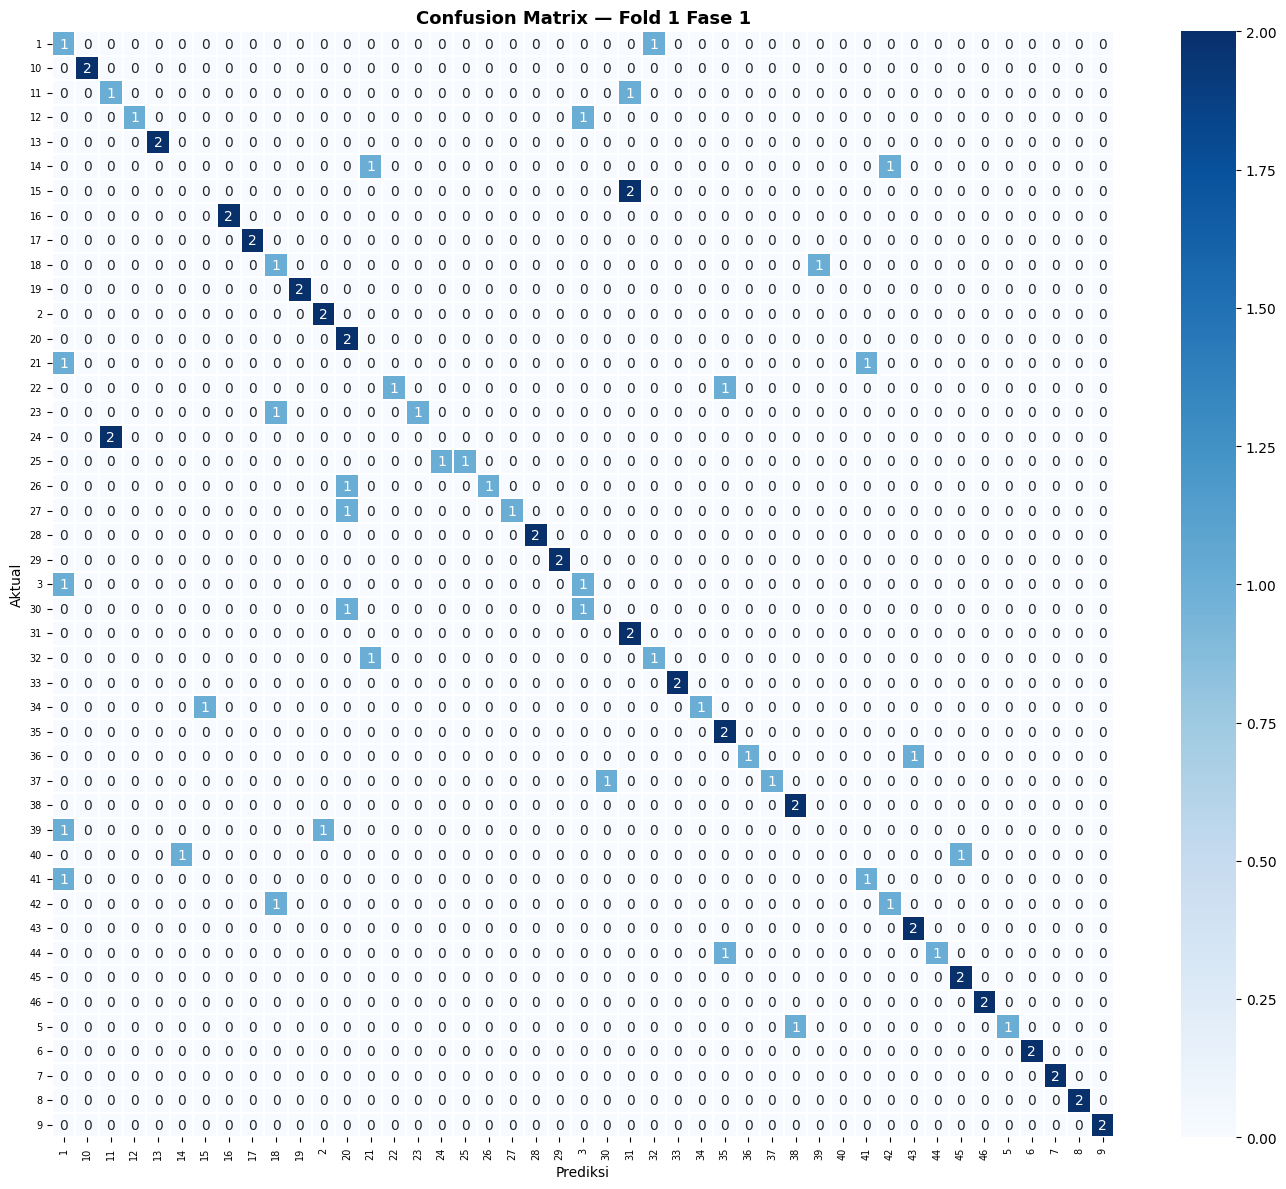


 Fold 1 — Fase 2
  Accuracy  : 0.6444 (64.44%)
  Precision : 0.6593
  F1 Macro  : 0.6170
  Recall    : 0.6444
File sudah ada, tidak ditimpa: /content/drive/Shareddrives/Projek PCD/output/models/cm_fold1_fase2.png


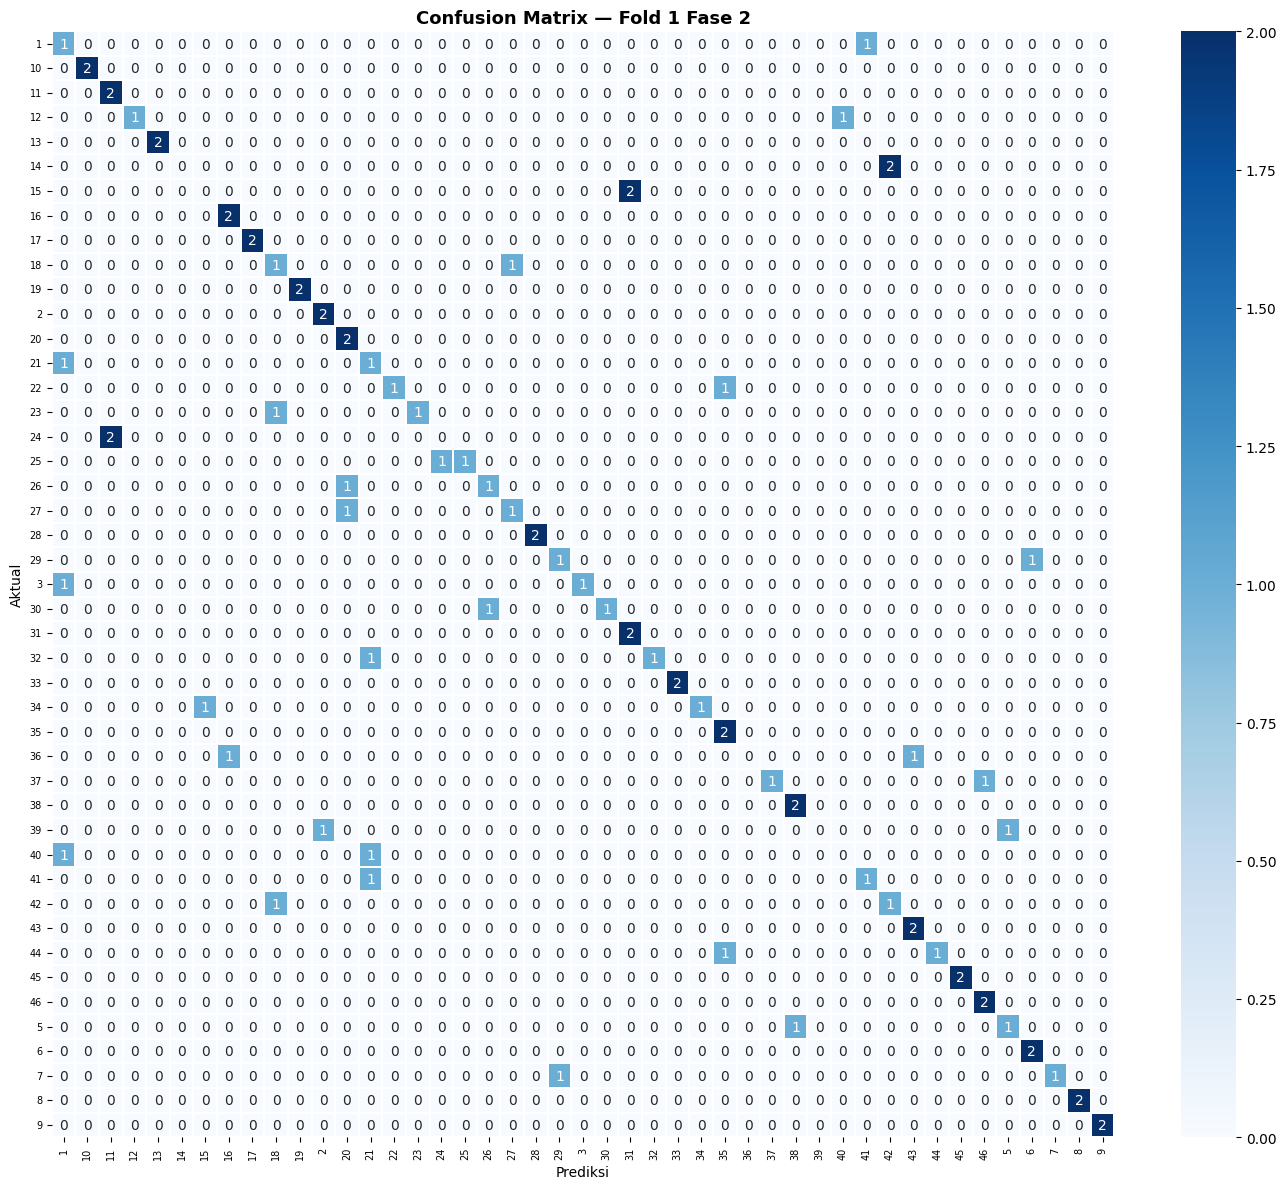


 Fold 2 — Fase 1
  Accuracy  : 0.5667 (56.67%)
  Precision : 0.6004
  F1 Macro  : 0.5479
  Recall    : 0.5667
File sudah ada, tidak ditimpa: /content/drive/Shareddrives/Projek PCD/output/models/cm_fold2_fase1.png


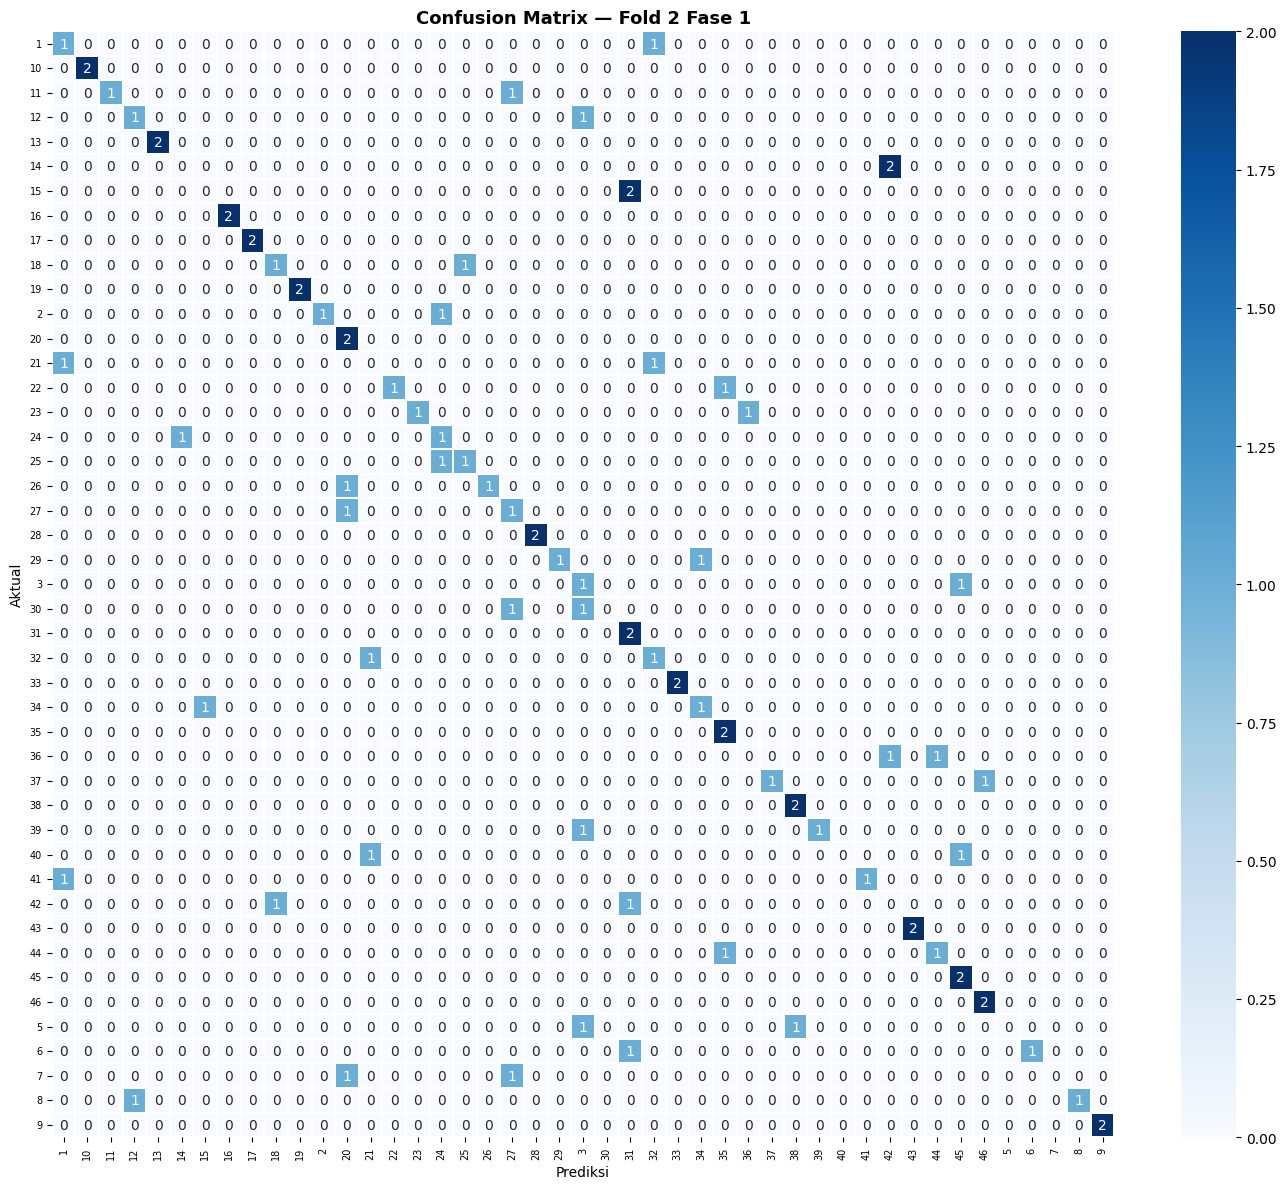


 Fold 2 — Fase 2
  Accuracy  : 0.6222 (62.22%)
  Precision : 0.6348
  F1 Macro  : 0.5979
  Recall    : 0.6222
File sudah ada, tidak ditimpa: /content/drive/Shareddrives/Projek PCD/output/models/cm_fold2_fase2.png


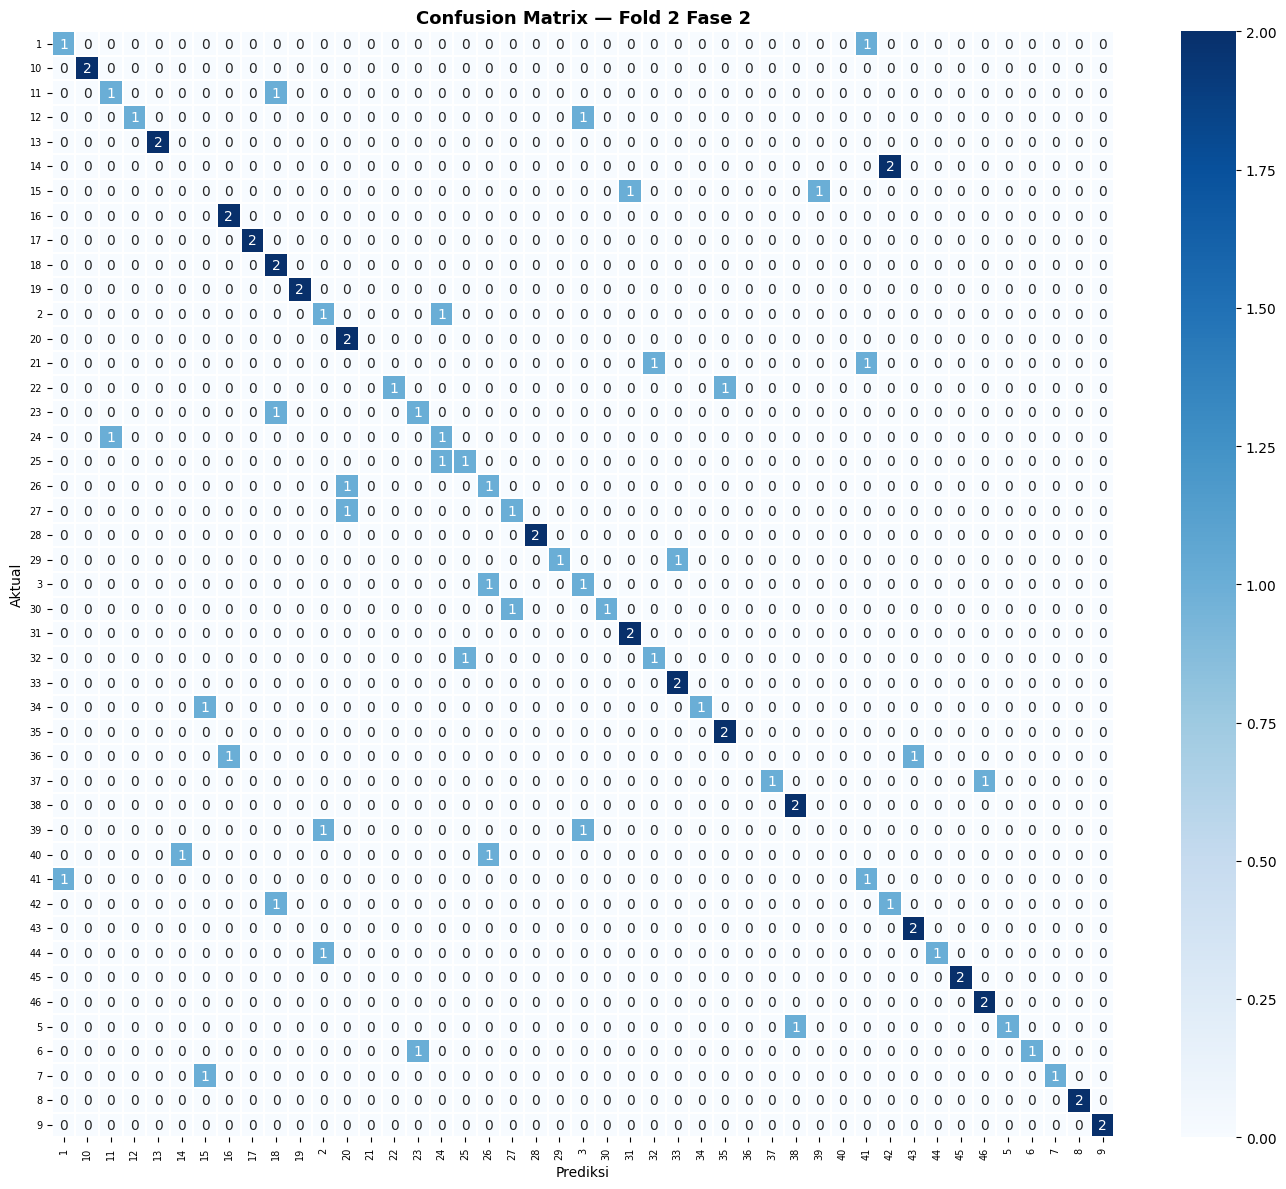


 Fold 3 — Fase 1
  Accuracy  : 0.5444 (54.44%)
  Precision : 0.5837
  F1 Macro  : 0.5265
  Recall    : 0.5444
File sudah ada, tidak ditimpa: /content/drive/Shareddrives/Projek PCD/output/models/cm_fold3_fase1.png


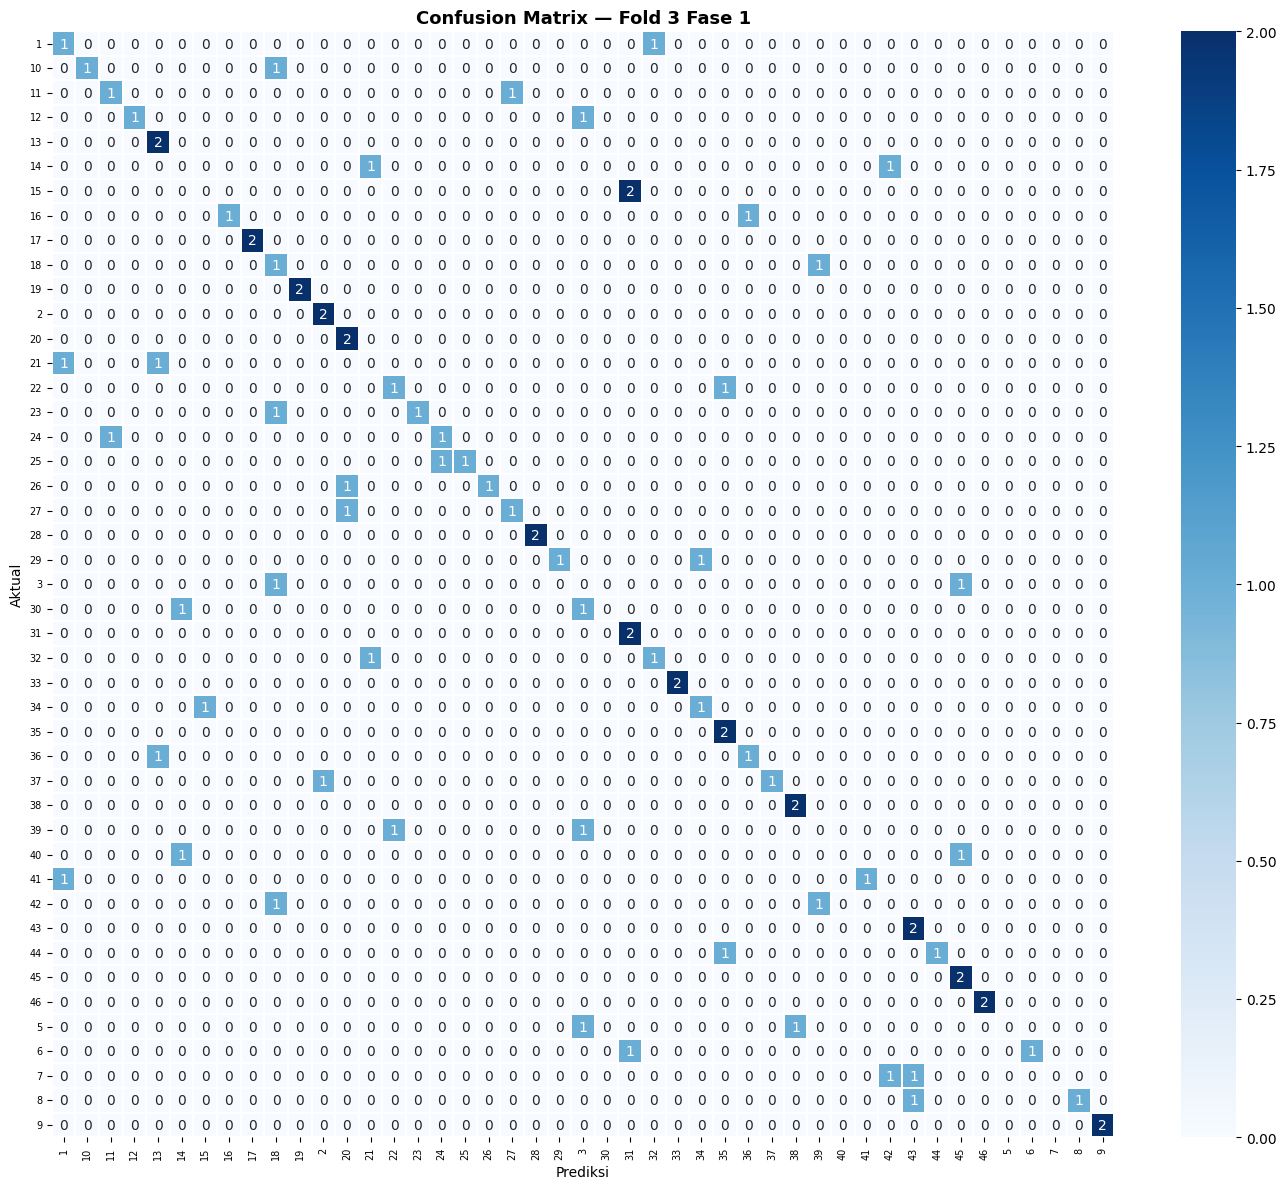


 Fold 3 — Fase 2
  Accuracy  : 0.6333 (63.33%)
  Precision : 0.6441
  F1 Macro  : 0.6090
  Recall    : 0.6333
File sudah ada, tidak ditimpa: /content/drive/Shareddrives/Projek PCD/output/models/cm_fold3_fase2.png


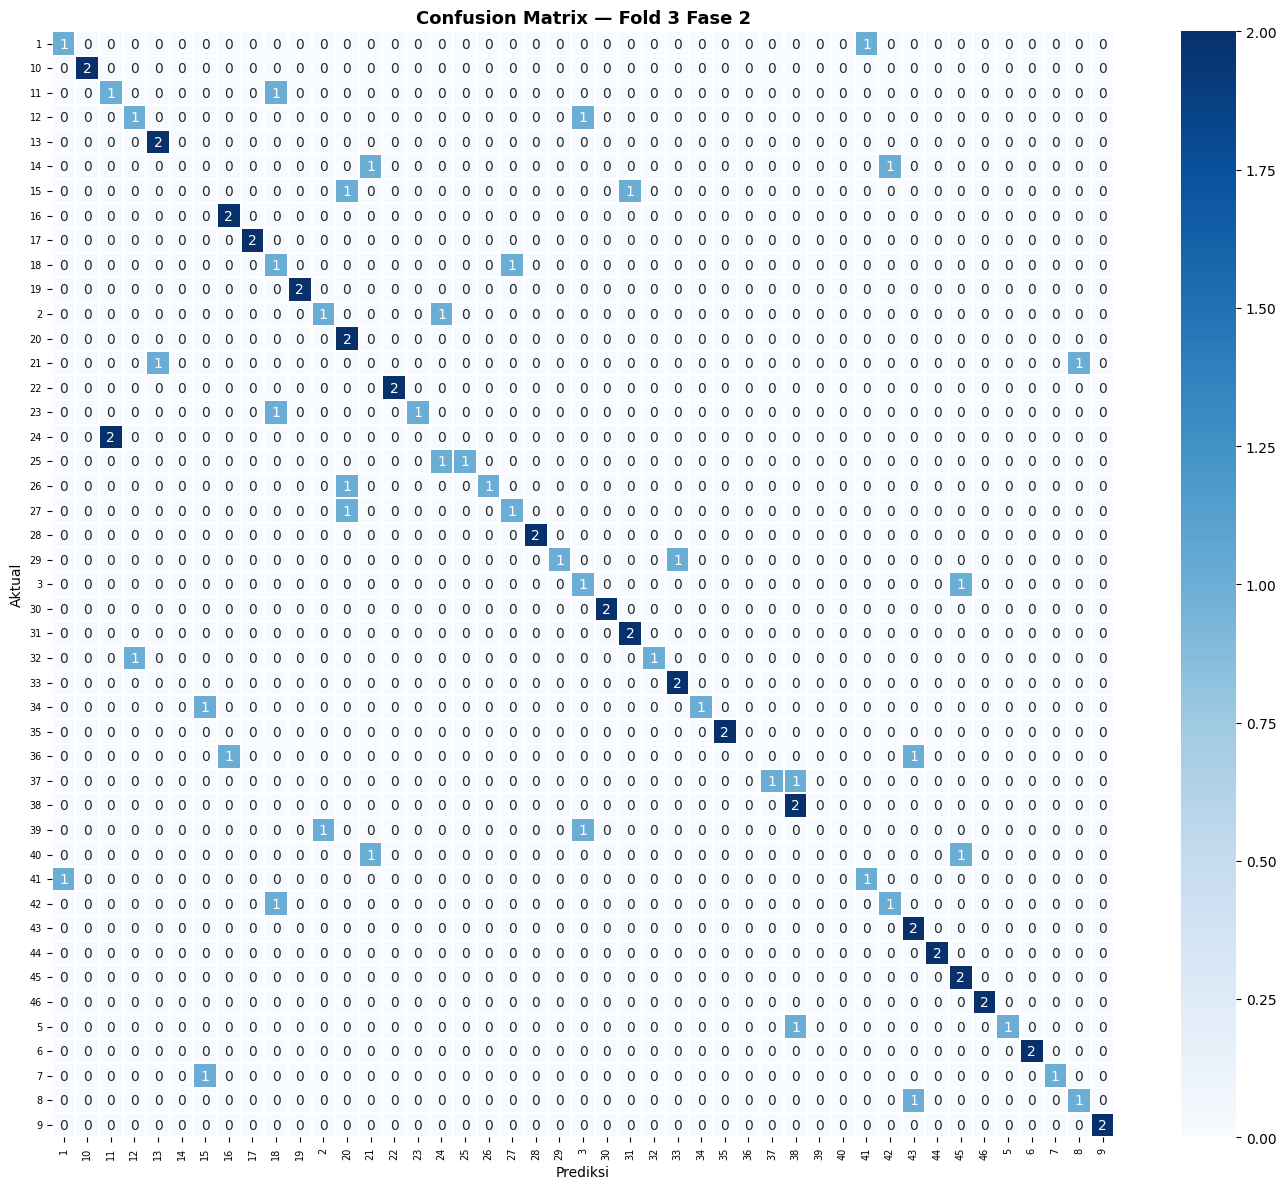


 Fold 4 — Fase 1
  Accuracy  : 0.5667 (56.67%)
  Precision : 0.5793
  F1 Macro  : 0.5386
  Recall    : 0.5667
File sudah ada, tidak ditimpa: /content/drive/Shareddrives/Projek PCD/output/models/cm_fold4_fase1.png


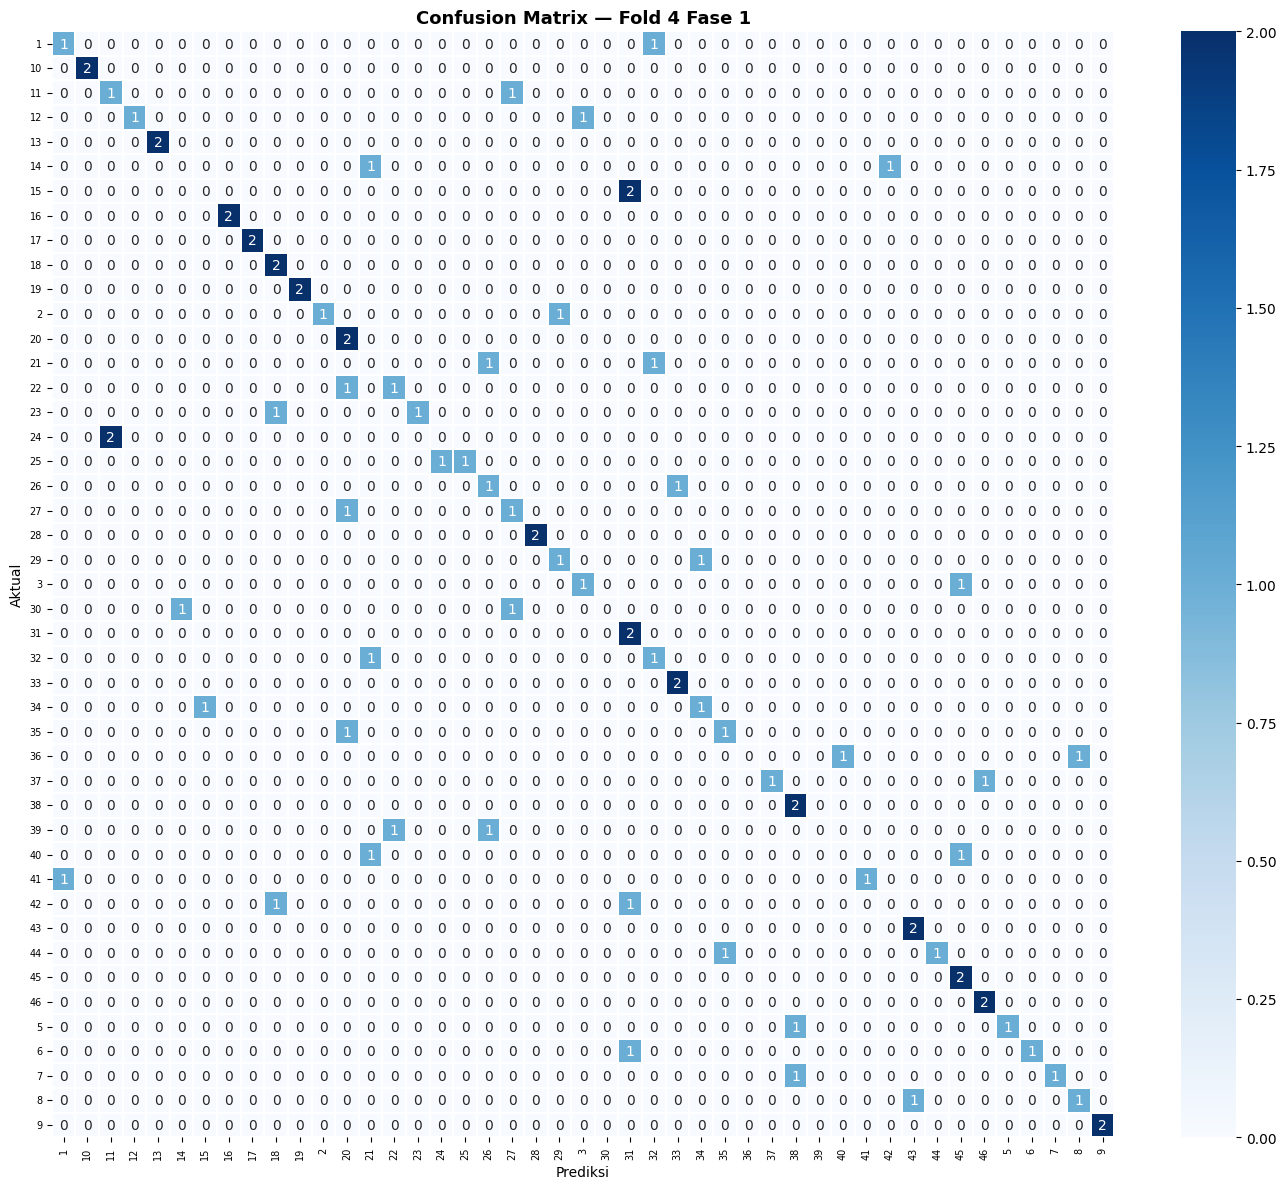


 Fold 4 — Fase 2
  Accuracy  : 0.6111 (61.11%)
  Precision : 0.6470
  F1 Macro  : 0.5945
  Recall    : 0.6111
File sudah ada, tidak ditimpa: /content/drive/Shareddrives/Projek PCD/output/models/cm_fold4_fase2.png


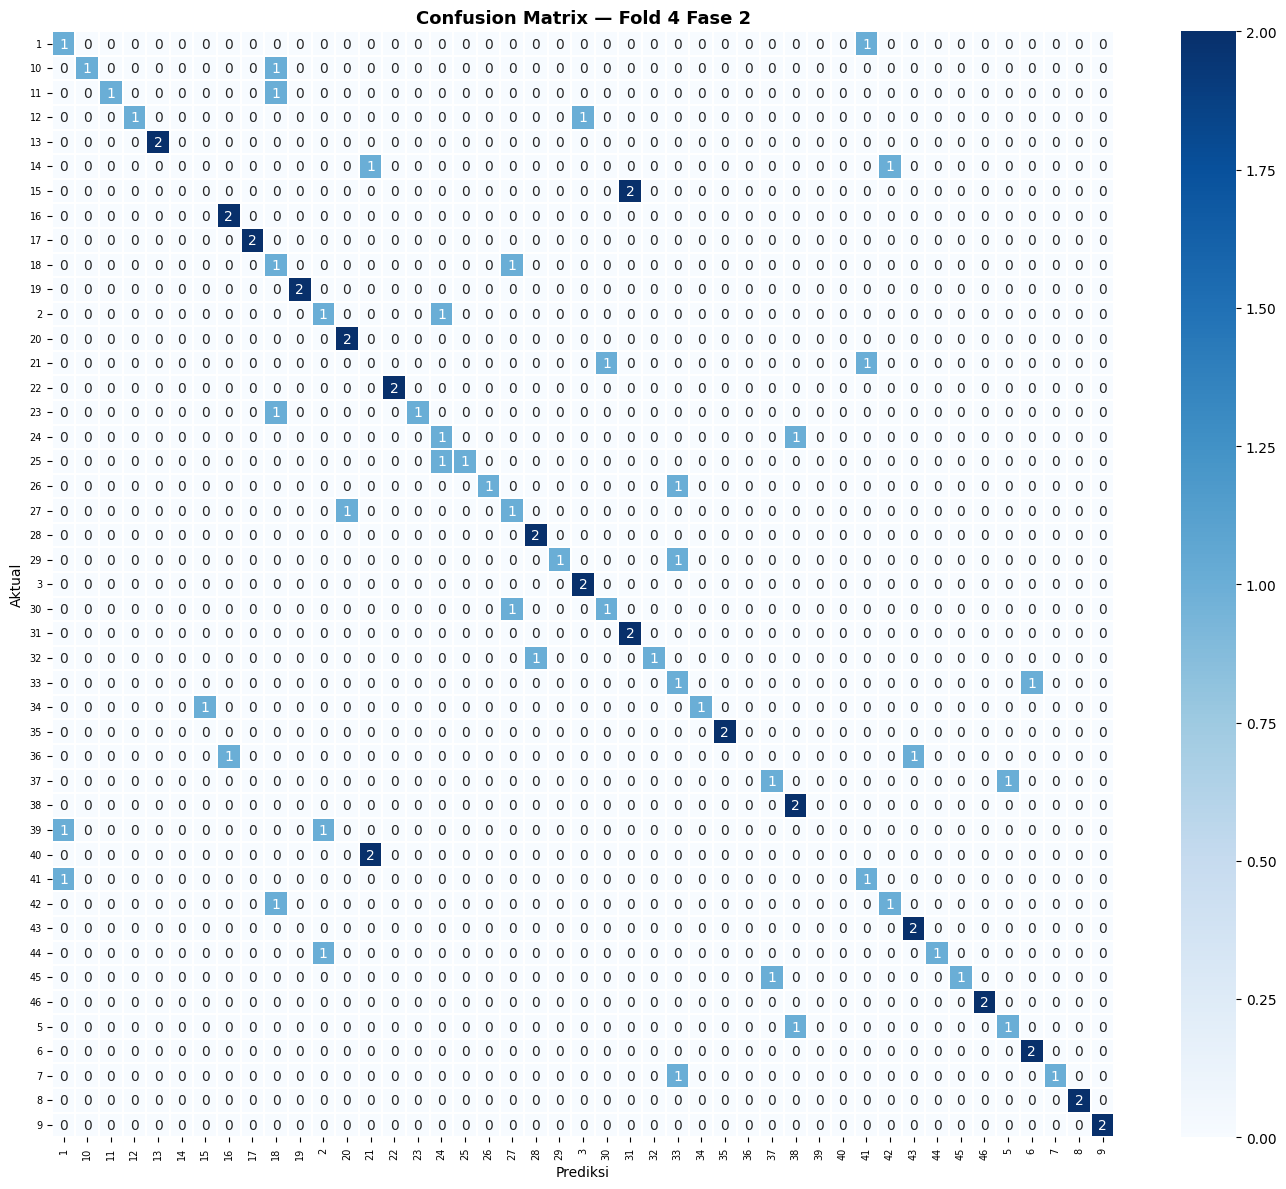


 Fold 5 — Fase 1
  Accuracy  : 0.5556 (55.56%)
  Precision : 0.5741
  F1 Macro  : 0.5295
  Recall    : 0.5556
File sudah ada, tidak ditimpa: /content/drive/Shareddrives/Projek PCD/output/models/cm_fold5_fase1.png


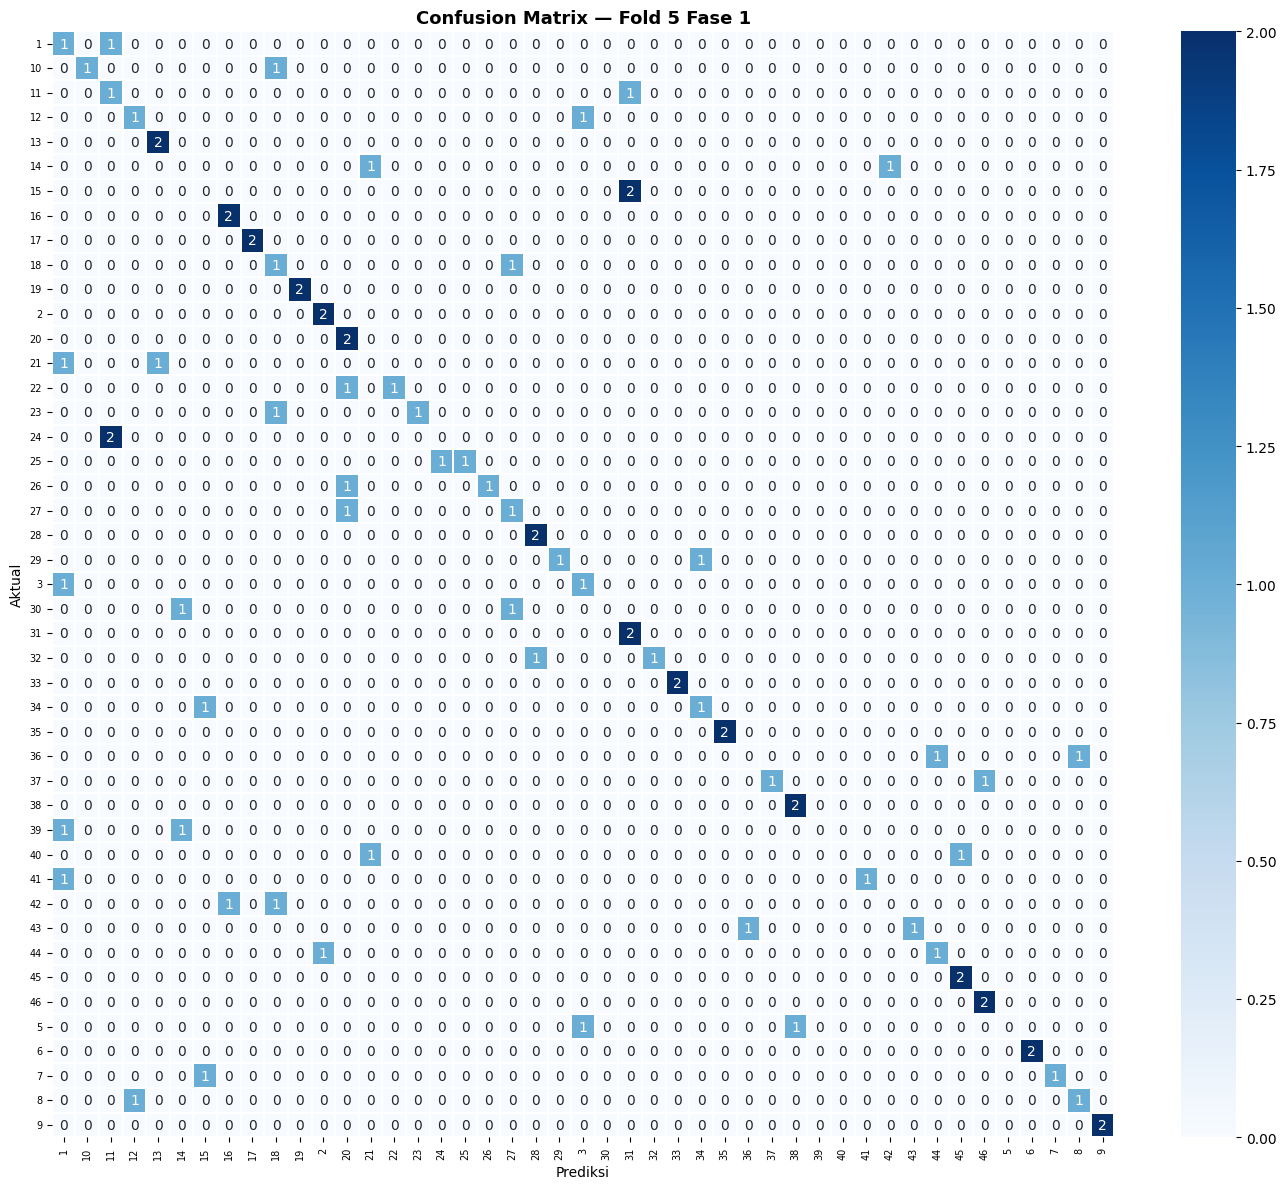


 Fold 5 — Fase 2
  Accuracy  : 0.6333 (63.33%)
  Precision : 0.6815
  F1 Macro  : 0.6244
  Recall    : 0.6333
File sudah ada, tidak ditimpa: /content/drive/Shareddrives/Projek PCD/output/models/cm_fold5_fase2.png


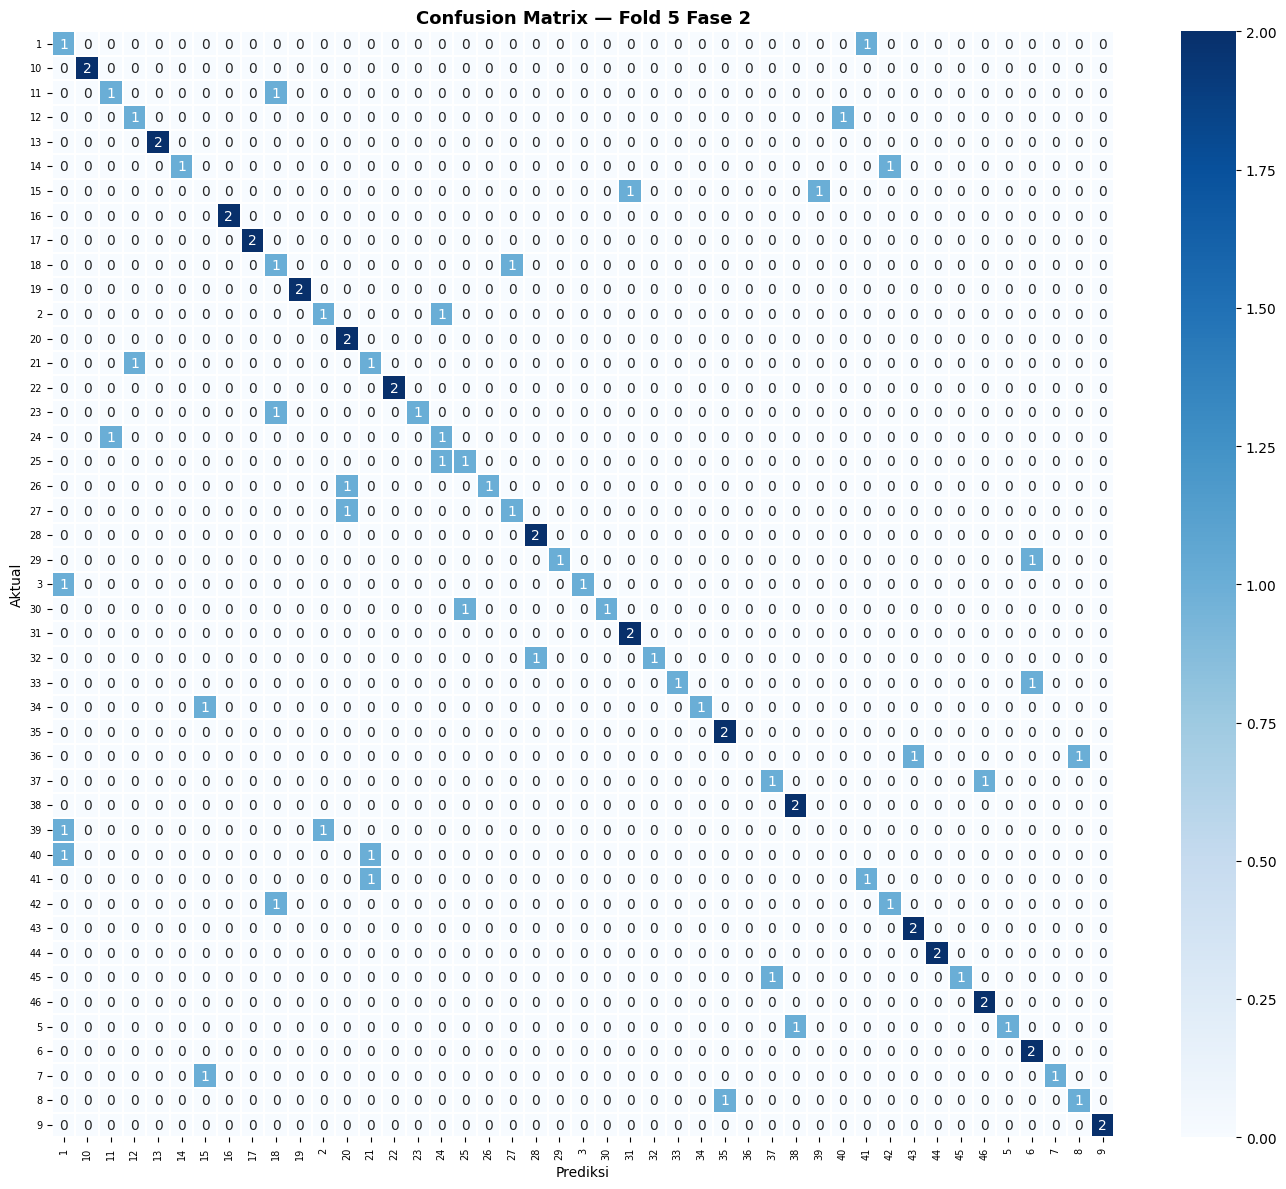


Ringkasan Evaluasi Semua Fold
 Fold   Fase Accuracy Precision (macro) F1 (macro) Recall (macro)
    1 Fase 1   0.6444            0.6815     0.6295         0.6444
    1 Fase 2   0.6444            0.6593     0.6170         0.6444
    2 Fase 1   0.5667            0.6004     0.5479         0.5667
    2 Fase 2   0.6222            0.6348     0.5979         0.6222
    3 Fase 1   0.5444            0.5837     0.5265         0.5444
    3 Fase 2   0.6333            0.6441     0.6090         0.6333
    4 Fase 1   0.5667            0.5793     0.5386         0.5667
    4 Fase 2   0.6111            0.6470     0.5945         0.6111
    5 Fase 1   0.5556            0.5741     0.5295         0.5556
    5 Fase 2   0.6333            0.6815     0.6244         0.6333

Tabel disimpan di: /content/drive/Shareddrives/Projek PCD/output/models/evaluasi_semua_fold.csv


In [ ]:
import joblib
from sklearn.metrics import (
    confusion_matrix, classification_report,
    f1_score, recall_score, accuracy_score, precision_score
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Kumpulkan semua label test (ground truth) sekali saja
def get_test_labels_and_preds(model, test_data):
    """Ambil y_true dan y_pred dari model tanpa training ulang."""
    test_gen = build_data_generator(test_data, batch_size=32, shuffle=False)
    y_pred_proba = model.predict(test_gen, verbose=0)
    y_pred = np.argmax(y_pred_proba, axis=1)
    y_true = np.array([item['encoded_label'] for item in test_data])
    return y_true, y_pred

# Tabel ringkasan semua fold
summary_rows = []

for fold_num in range(1, 6):
    for fase, weight_filename in [('Fase 1', f'model_fold_{fold_num}_phase1_best.h5'),
                                   ('Fase 2', f'model_fold_{fold_num}_best.h5')]:
        weight_path = os.path.join(MODEL_PATH, weight_filename)

        if not os.path.exists(weight_path):
            print(f"[SKIP] Fold {fold_num} {fase}: file tidak ada ({weight_filename})")
            continue

        # Load model
        model, _ = build_model(NUM_CLASSES, dropout_rate=0.2, l2_reg=1e-4)
        model.compile(
            optimizer=Adam(learning_rate=1e-5),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )
        model.load_weights(weight_path)

        # Prediksi
        y_true, y_pred = get_test_labels_and_preds(model, test_norm_results)

        # Hitung metrik
        acc       = accuracy_score(y_true, y_pred)
        prec      = precision_score(y_true, y_pred, average='macro', zero_division=0)
        f1        = f1_score(y_true, y_pred, average='macro', zero_division=0)
        recall    = recall_score(y_true, y_pred, average='macro', zero_division=0)

        summary_rows.append({
            'Fold': fold_num,
            'Fase': fase,
            'Accuracy': f"{acc:.4f}",
            'Precision (macro)': f"{prec:.4f}",
            'F1 (macro)': f"{f1:.4f}",
            'Recall (macro)': f"{recall:.4f}"
        })

        print(f"\n Fold {fold_num} — {fase}")
        print(f"  Accuracy  : {acc:.4f} ({acc*100:.2f}%)")
        print(f"  Precision : {prec:.4f}")
        print(f"  F1 Macro  : {f1:.4f}")
        print(f"  Recall    : {recall:.4f}")

        # Confusion Matrix
        cm = confusion_matrix(y_true, y_pred)
        class_names = le.classes_

        fig, ax = plt.subplots(figsize=(14, 12))
        sns.heatmap(
            cm,
            annot=True, fmt='d',
            cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names,
            ax=ax,
            linewidths=0.3
        )
        ax.set_title(f'Confusion Matrix — Fold {fold_num} {fase}',
                     fontsize=13, fontweight='bold')
        ax.set_xlabel('Prediksi')
        ax.set_ylabel('Aktual')
        plt.xticks(rotation=90, fontsize=7)
        plt.yticks(rotation=0,  fontsize=7)
        plt.tight_layout()

        cm_path = os.path.join(MODEL_PATH,
                    f'cm_fold{fold_num}_{fase.lower().replace(" ","")}.png')
        if not os.path.exists(cm_path):
            plt.savefig(cm_path, dpi=150, bbox_inches='tight')
            print(f"Confusion matrix disimpan: {cm_path}")
        else:
            print(f"File sudah ada, tidak ditimpa: {cm_path}")
        plt.show()

# Tabel Ringkasan Semua Fold
print("\n" + "="*40)
print("Ringkasan Evaluasi Semua Fold")
print("="*40)
df_summary = pd.DataFrame(summary_rows)
print(df_summary.to_string(index=False))

# Simpan ke CSV
summary_path = os.path.join(MODEL_PATH, 'evaluasi_semua_fold.csv')
df_summary.to_csv(summary_path, index=False)
print(f"\nTabel disimpan di: {summary_path}")

In [ ]:
final_model, _ = build_model(NUM_CLASSES, dropout_rate=0.2, l2_reg=1e-4)

# TAMBAHKAN compile sebelum evaluate
final_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

best_path_fold1 = best_model_paths[0]
if os.path.exists(best_path_fold1):
    final_model.load_weights(best_path_fold1)
    print(f"Bobot model terbaik Fold 1 dimuat dari: {best_path_fold1}")

    test_gen = build_data_generator(test_norm_results, batch_size=32, shuffle=False)

    eval_results = final_model.evaluate(test_gen, verbose=1)
    print(f"\nEvaluasi pada data test (model Fold 1 terbaik):")
    print(f"Loss    : {eval_results[0]:.4f}")
    print(f"Accuracy: {eval_results[1]:.4f} ({eval_results[1]*100:.2f}%)")
else:
    print(f"File bobot tidak ditemukan: {best_path_fold1}")

print("\n*Pipeline Modeling Selesai*")
print(f"Model terbaik per fold disimpan di: {MODEL_PATH}")
print(f"History per fold disimpan di: {MODEL_PATH}")
print(f"Plot training per fold disimpan di: {MODEL_PATH}")
print(f"Label encoder disimpan di: {encoder_path}")

Bobot model terbaik Fold 1 dimuat dari: /content/drive/Shareddrives/Projek PCD/output/models/model_fold_1_best.h5
3/3 [==============================] - 2s 168ms/step - loss: 1.4399 - accuracy: 0.6444

Evaluasi pada data test (model Fold 1 terbaik):
Loss    : 1.4399
Accuracy: 0.6444 (64.44%)

*Pipeline Modeling Selesai*
Model terbaik per fold disimpan di: /content/drive/Shareddrives/Projek PCD/output/models
History per fold disimpan di: /content/drive/Shareddrives/Projek PCD/output/models
Plot training per fold disimpan di: /content/drive/Shareddrives/Projek PCD/output/models
Label encoder disimpan di: /content/drive/Shareddrives/Projek PCD/output/models/label_encoder.pkl


In [ ]:
# Membandingkan statistik pixel
import cv2
import numpy as np
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

def sample_pixel_stats(data_list, n_sample=10, label='data'):
    means, stds = [], []
    key = 'img_path' if 'img_path' in data_list[0] else 'norm_path'
    for item in data_list[:n_sample]:
        img = cv2.imread(item[key])
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (96, 96))
        img = preprocess_input(img.astype(np.float32))
        means.append(img.mean())
        stds.append(img.std())
    print(f"{label} — mean pixel: {np.mean(means):.4f}, std pixel: {np.mean(stds):.4f}")

sample_pixel_stats(aug_train_results, label='aug_train_results')
sample_pixel_stats(test_norm_results, label='test_norm_results ')

aug_train_results — mean pixel: 0.2240, std pixel: 0.4369
test_norm_results  — mean pixel: 0.0018, std pixel: 0.4411


In [ ]:
import cv2
import numpy as np

# Baca 1 gambar test RAW sebelum preprocess apapun
test_item = test_norm_results[0]
key = 'img_path' if 'img_path' in test_item else 'norm_path'

img_raw = cv2.imread(test_item[key])
img_rgb = cv2.cvtColor(img_raw, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img_rgb, (96, 96))

print(f"Nilai pixel SEBELUM preprocess_input:")
print(f"  min : {img_resized.min()}")
print(f"  max : {img_resized.max()}")
print(f"  mean: {img_resized.mean():.4f}")

# Bandingkan dengan gambar train
train_item = aug_train_results[0]
key_train = 'img_path' if 'img_path' in train_item else 'norm_path'

img_train = cv2.imread(train_item[key_train])
img_train = cv2.cvtColor(img_train, cv2.COLOR_BGR2RGB)
img_train = cv2.resize(img_train, (96, 96))

print(f"\nNilai pixel SEBELUM preprocess_input (train):")
print(f"  min : {img_train.min()}")
print(f"  max : {img_train.max()}")
print(f"  mean: {img_train.mean():.4f}")

Nilai pixel SEBELUM preprocess_input:
  min : 0
  max : 196
  mean: 78.2818

Nilai pixel SEBELUM preprocess_input (train):
  min : 0
  max : 240
  mean: 161.8576


Membuat Confusion Matrix dan Classification Report untuk Final Model (Fold 1) dengan Test Data Asli...
Bobot model terbaik Fold 1 dimuat dari: /content/drive/Shareddrives/Projek PCD/output/models/model_fold_1_best.h5

--- Classification Report ---
              precision    recall  f1-score   support

           1       0.25      0.50      0.33         2
          10       1.00      1.00      1.00         2
          11       0.50      1.00      0.67         2
          12       1.00      0.50      0.67         2
          13       1.00      1.00      1.00         2
          14       0.00      0.00      0.00         2
          15       0.00      0.00      0.00         2
          16       0.67      1.00      0.80         2
          17       1.00      1.00      1.00         2
          18       0.33      0.50      0.40         2
          19       1.00      1.00      1.00         2
           2       0.67      1.00      0.80         2
          20       0.50      1.00      0.67      

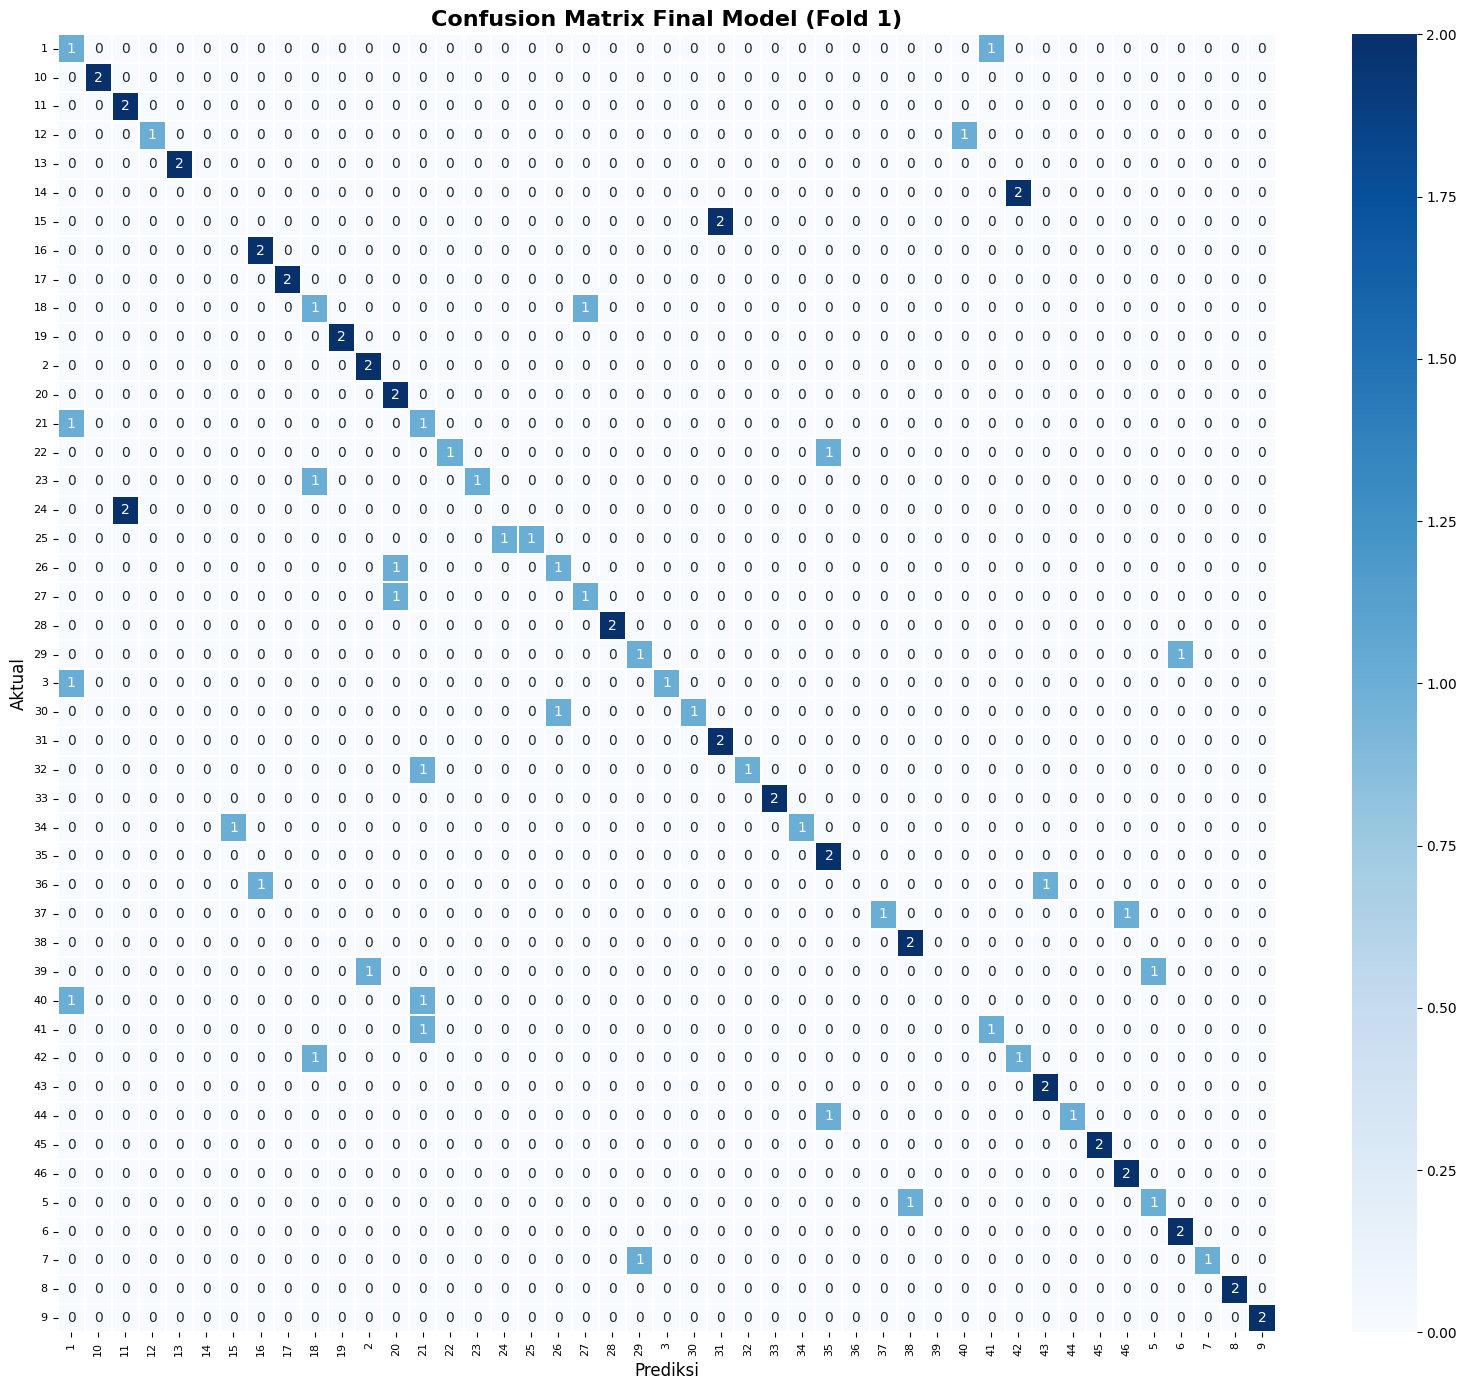

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from tensorflow.keras.optimizers import Adam

print("Membuat Confusion Matrix dan Classification Report untuk Final Model (Fold 1) dengan Test Data Asli...")

# Memuat model terbaik dari Fold 1
final_model, _ = build_model(NUM_CLASSES, dropout_rate=0.2, l2_reg=1e-4)
final_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

best_path_fold1 = os.path.join(MODEL_PATH, 'model_fold_1_best.h5') # Assume Fold 1 is the 'final' model based on previous cells

if os.path.exists(best_path_fold1):
    final_model.load_weights(best_path_fold1)
    print(f"Bobot model terbaik Fold 1 dimuat dari: {best_path_fold1}")

    # Mempersiapkan data test
    test_gen = build_data_generator(test_norm_results, batch_size=32, shuffle=False)

    # Mendapatkan prediksi
    y_pred_proba = final_model.predict(test_gen, verbose=0)
    y_pred = np.argmax(y_pred_proba, axis=1)
    y_true = np.array([item['encoded_label'] for item in test_norm_results])

    # Mendapatkan nama kelas dari label encoder
    class_names = le.classes_

    print("\n--- Classification Report ---")
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

    print("\n--- Confusion Matrix ---")
    # Membuat confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    # Visualisasi confusion matrix
    fig, ax = plt.subplots(figsize=(16, 14))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names,
        ax=ax,
        linewidths=0.3
    )
    ax.set_title('Confusion Matrix Final Model (Fold 1)',
                 fontsize=16, fontweight='bold')
    ax.set_xlabel('Prediksi', fontsize=12)
    ax.set_ylabel('Aktual', fontsize=12)
    plt.xticks(rotation=90, fontsize=8)
    plt.yticks(rotation=0,  fontsize=8)
    plt.tight_layout()

    # Simpan confusion matrix
    cm_final_path = os.path.join(MODEL_PATH, 'cm_final_model_fold1_test_data.png')
    plt.savefig(cm_final_path, dpi=150, bbox_inches='tight')
    print(f"Confusion matrix disimpan: {cm_final_path}")
    plt.show()

else:
    print(f"File bobot tidak ditemukan: {best_path_fold1}. Pastikan training sudah selesai.")


In [ ]:
print("\n--- Ringkasan Metrik Evaluasi ---\n")
print(df_summary.to_markdown(index=False))


--- Ringkasan Metrik Evaluasi ---

|   Fold | Fase   |   Accuracy |   Precision (macro) |   F1 (macro) |   Recall (macro) |
|-------:|:-------|-----------:|--------------------:|-------------:|-----------------:|
|      1 | Fase 1 |     0.6444 |              0.6815 |       0.6295 |           0.6444 |
|      1 | Fase 2 |     0.6444 |              0.6593 |       0.617  |           0.6444 |
|      2 | Fase 1 |     0.5667 |              0.6004 |       0.5479 |           0.5667 |
|      2 | Fase 2 |     0.6222 |              0.6348 |       0.5979 |           0.6222 |
|      3 | Fase 1 |     0.5444 |              0.5837 |       0.5265 |           0.5444 |
|      3 | Fase 2 |     0.6333 |              0.6441 |       0.609  |           0.6333 |
|      4 | Fase 1 |     0.5667 |              0.5793 |       0.5386 |           0.5667 |
|      4 | Fase 2 |     0.6111 |              0.647  |       0.5945 |           0.6111 |
|      5 | Fase 1 |     0.5556 |              0.5741 |       0.5295 |     